# Simulations

Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import simulations
import pandas as pd
import mne
import sys

sys.path.insert(1, '../')

from unfold import unfold_utils, unfold_model 
from functools import partial

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


  Activating project at `~/Projects/neuroNoodle/simulation`


Status `~/Projects/neuroNoodle/simulation/Project.toml`
  [a93c6f00] DataFrames v1.7.0
  [181c99d8] Unfold v0.7.6
None
  [ec0f67a1] UnfoldDecode v0.1.0 `https://github.com/unfoldtoolbox/UnfoldDecode.jl#main`


   Resolving package versions...
  No Changes to `~/Projects/neuroNoodle/simulation/Project.toml`
  No Changes to `~/Projects/neuroNoodle/simulation/Manifest.toml`
Precompiling project...
  ✓ NNlib → NNlibFFTWExt
  1 dependency successfully precompiled in 5 seconds. 229 already precompiled.
   Resolving package versions...
  No Changes to `~/Projects/neuroNoodle/simulation/Project.toml`
  No Changes to `~/Projects/neuroNoodle/simulation/Manifest.toml`
Precompiling project...
  ✓ NNlib → NNlibForwardDiffExt
  ✓ MLUtils
  ✓ StatisticalMeasuresBase
  ✓ MLJEnsembles
  ✓ MLJBase
  ✓ StatisticalMeasures
  ✓ StatisticalMeasures → ScientificTypesExt
  ✓ MLJBase → DefaultMeasuresExt
  ✓ MLJFlow
  ✓ MLJTuning
  ✓ MLJBalancing
  ✓ MLJIteration
  ✓ MLJ
  ✓ UnfoldDecode
  14 dependencies successfully precompiled in 19 seconds. 216 already precompiled.
    Updating git-repo `https://github.com/unfoldtoolbox/UnfoldDecode.jl`
   Resolving package versions...
  No Changes to `~/Projects/neuroNoodle/sim

## 1. Simple simulation

Config

In [41]:
# Parameters
n_trials_per_ssd = 100
distances_C_A = np.arange(0.1, 0.4, 0.05)
sampling_rate = 64
noise_level = 0
duration=1.5
sri_mean = 0.1
channels = ['Fz', 'Cz']

config = {
    'go_intercept': .2,
    'stop_intercept': .5,
    'response_intercept':
        {
            'error': 1,
            'correct_nostop':.2
        },
    'interactions': {
        'stop x SSD': True,
        'response_error x SSD': True,
        'response_error x SRI': True,
    },
    'probability': {
        'stop': 0.3,
        'error': 0.5,

    },
    'sri': {'loc': sri_mean, 'scale': 0.05}
}

Simulate data

In [42]:
# Simulate ERP components with conditions
erp_trials, data_df = simulations.simulate_erp_components_with_conditions_test(
    n_trials_per_ssd,
    distances_C_A,
    config,
    sampling_rate,
    noise_level,
    duration=duration,
    stop_diff=True,
    remove_ern=False,
    stop_component_offset = 0.15,
)

# create Unfold events dataset
events_df = simulations.create_events_table(data_df, duration, sampling_rate)
events = {'Fz': events_df, 'Cz': events_df}
raw = np.ravel(erp_trials)

### Perform unfolding

Define unfold model

In [43]:
current_unfold_model = unfold_model.get_basic_model()

Perform unfolding

In [44]:
results_channels = dict()
for channel in channels:
    channel_events_df = events[channel]
    # get EEG data
    eeg_data = raw.reshape(1,-1)
    
    results_channel, num_parameters = unfold_model.perform_unfold(channel_events_df, eeg_data, current_unfold_model)
    results_channels[channel] = results_channel

### Basic visualization

SRI mean: 0.1


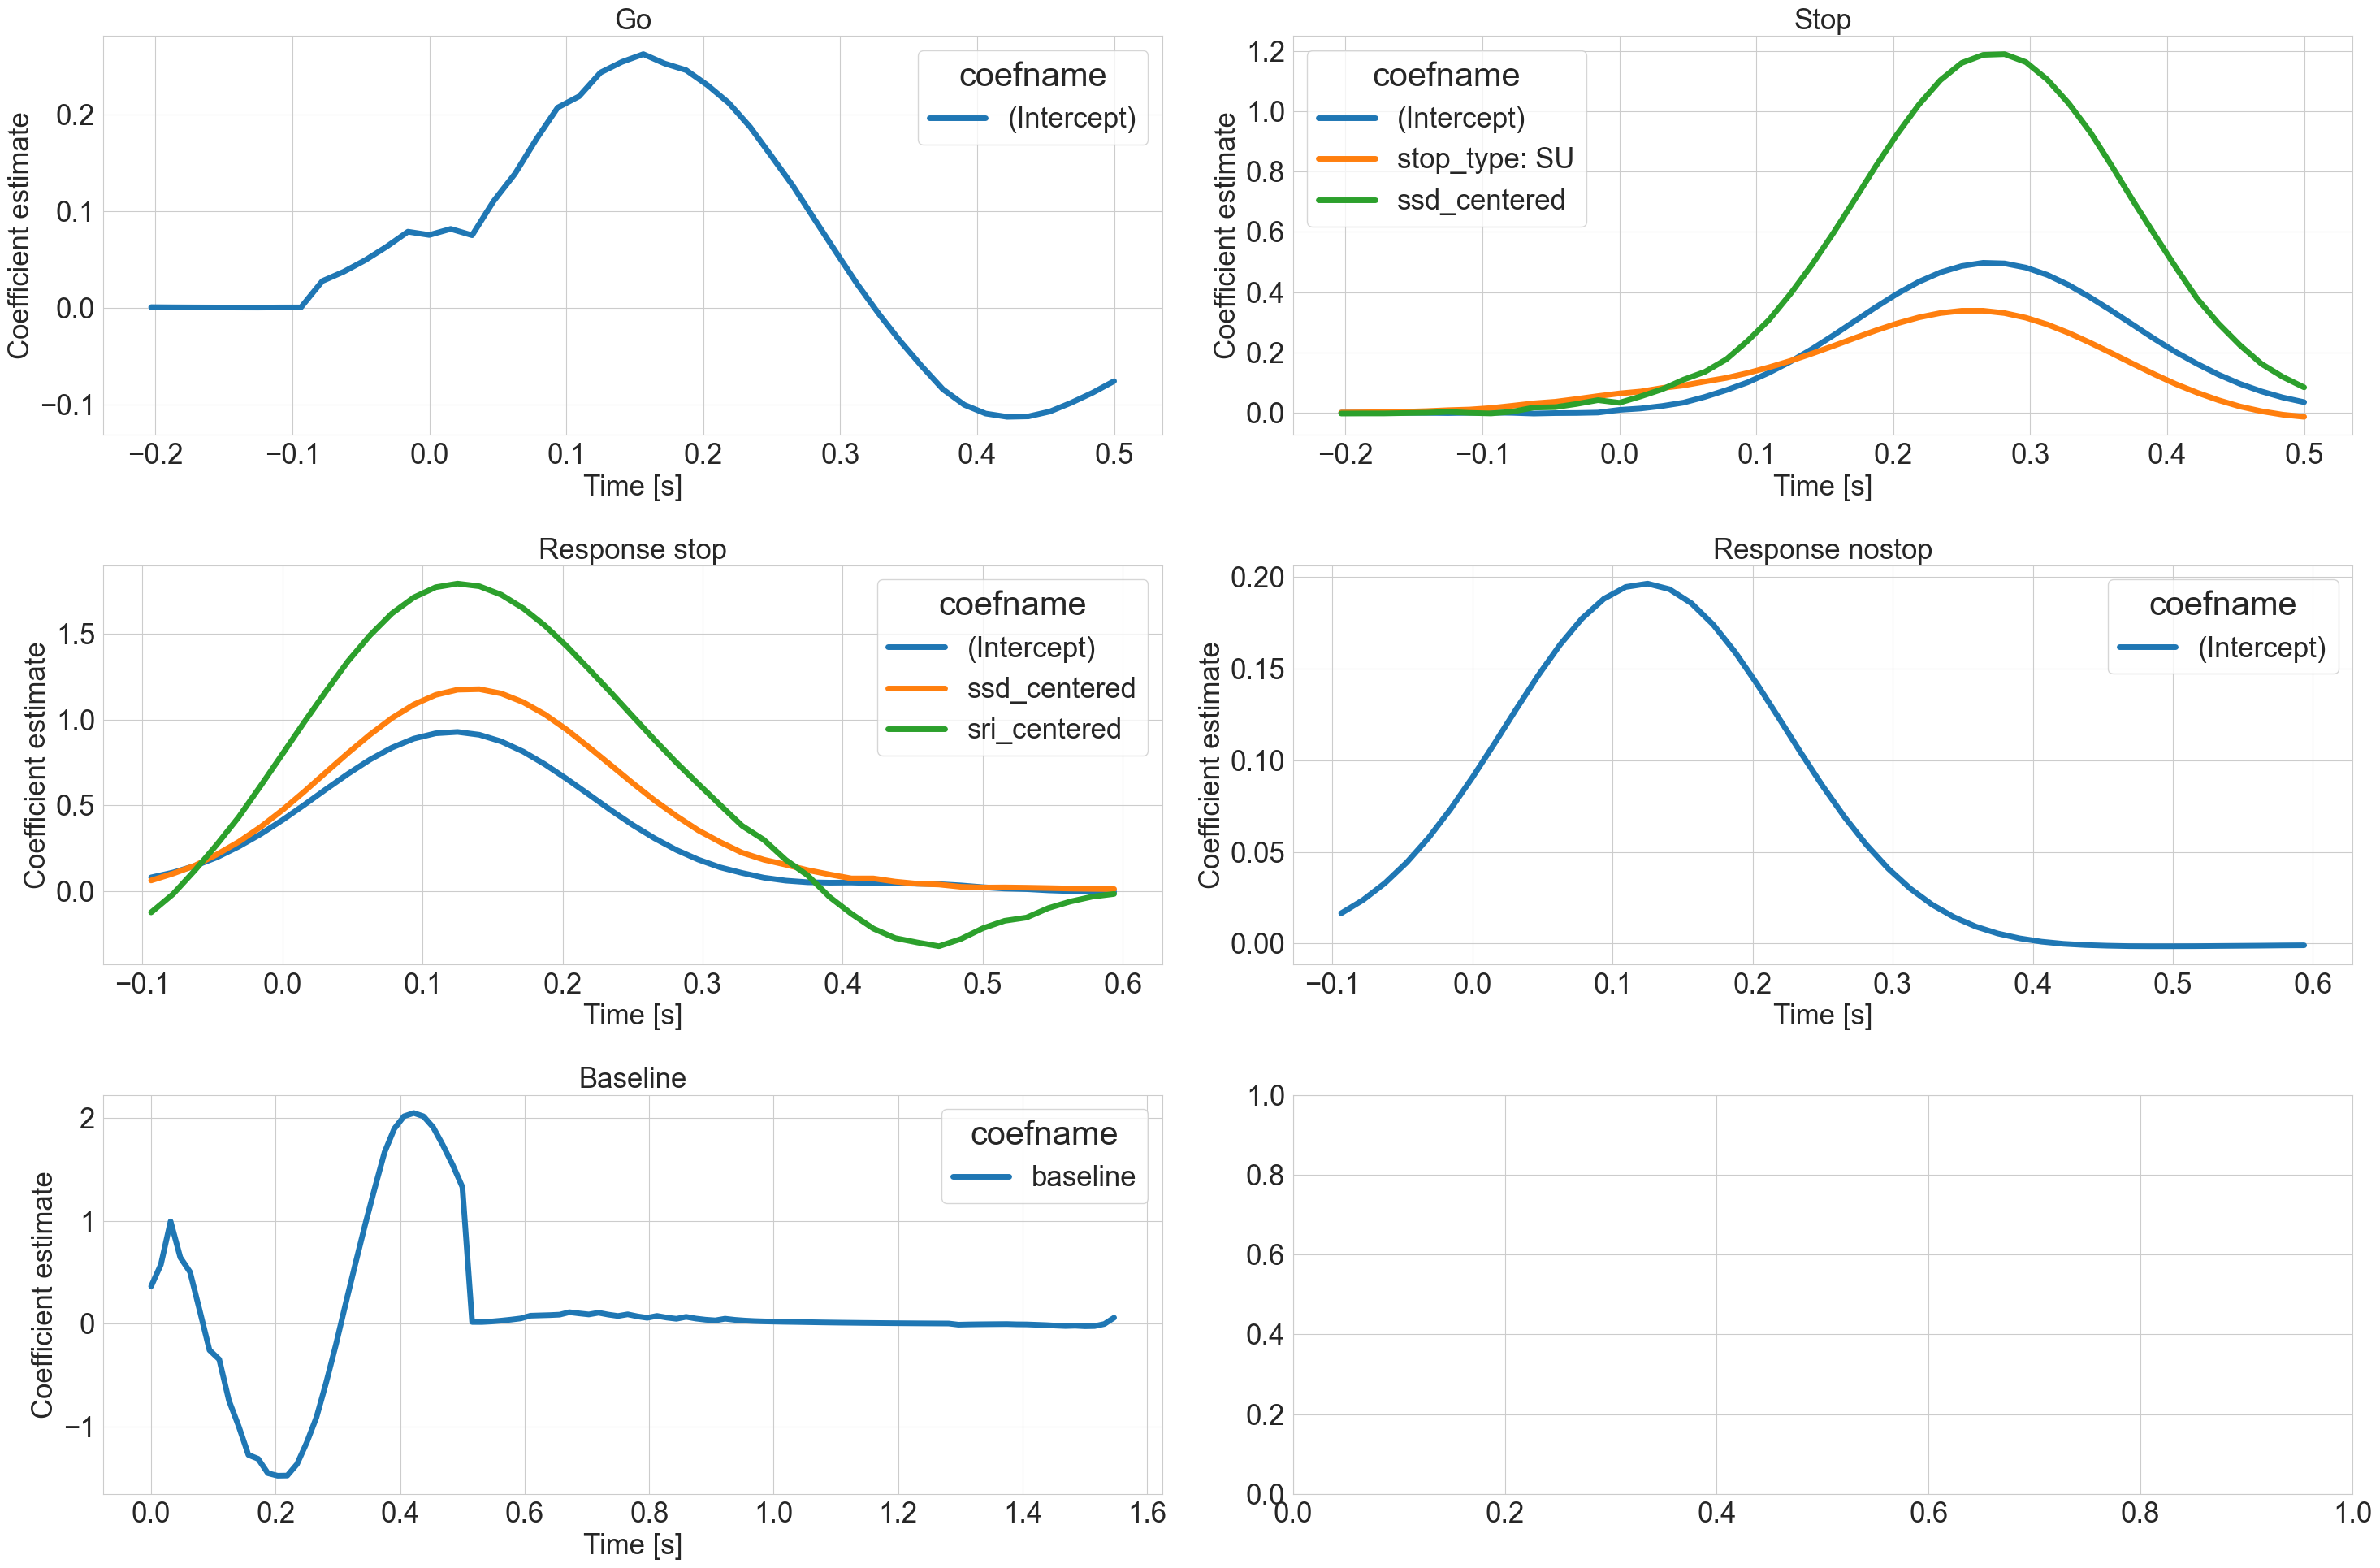

In [45]:
# plot results
import seaborn as sns
print(f'SRI mean: {sri_mean}')
unfold_utils.plot_unfold_results_effects(results_channels['Fz'])

### Vizualize interactive

In [7]:
event_names = ['baseline', 'go', 'stop', 'response_stop', 'response_nostop', 'evoked']
results_list = []

person_unfolded = unfold_utils.ResultsContainer(event_names=event_names)
person_unfolded.num_parameters = num_parameters
person_unfolded.process_results(results_channels)
person_unfolded.person_id = 'A1'
results_list.append(person_unfolded)

average_results = unfold_utils.ResultsContainer.create_average([person_unfolded])
average_results.estimate_aic()
results_list.append(average_results)

unfold_utils.plot_results_containers(results_list)

Dropdown(description='Select ID:', options=('A1', 'all'), value='A1')

Dropdown(description='Event Name:', options=('baseline', 'evoked', 'go', 'response_nostop', 'response_stop', '…

Dropdown(description='Electrode:', index=1, options=('Fz', 'Cz'), value='Cz')

Output()

---
## 2. Check the influence of mean SRI on the EEG signal
### 2.1 ERN is present

In [22]:
def simulate_unfolded_data(current_unfold_model, sri_mean=0.2):
    # Parameters
    n_trials_per_ssd = 100
    distances_C_A = np.arange(0.1, 0.4, 0.05)
    sampling_rate = 64
    noise_level = 0
    duration=1.5
    channels = ['Fz', 'Cz']
    
    config = {
        'go_intercept': 2,
        'stop_intercept': 5,
        'response_intercept':
            {
                'error': 10,
                'correct_nostop':2
            },
        'interactions': {
            'stop x SSD': True,
            'response_error x SSD': True,
            'response_error x SRI': True,
        },
        'probability': {
            'stop': 0.3,
            'error': 0.5,
    
        },
        'sri': {'loc': sri_mean, 'scale': 0.05}
    }
    
    # Simulate ERP components with conditions
    erp_trials, data_df = simulations.simulate_erp_components_with_conditions_test(
        n_trials_per_ssd,
        distances_C_A,
        config,
        sampling_rate,
        noise_level,
        duration=duration,
        stop_diff=True,
        remove_ern=False,
        stop_component_offset = 0.15,
    )
    
    # create Unfold events dataset
    events_df = simulations.create_events_table(data_df, duration, sampling_rate)

    events = {'Fz': events_df, 'Cz': events_df}

    raw = np.ravel(erp_trials)

    results_channels = dict()
    for channel in channels:
        channel_events_df = events[channel]
        # get EEG data
        eeg_data = raw.reshape(1,-1)

        # cast EEG data from V to uV
        eeg_data = eeg_data * 1000000
        
        results_channel_df, num_parameters = unfold_model.perform_unfold(
            channel_events_df,
            eeg_data,
            current_unfold_model
        )
        results_channels[channel] = results_channel_df

    return results_channels, num_parameters

### 2.1.1 Basic model

In [23]:
# define unfold model
current_unfold_model = unfold_model.get_basic_model()

# partially define sumulation function with the unfold model
simulate_with_model = partial(simulate_unfolded_data, current_unfold_model)

unfold_utils.plot_results_dict_sri(
    data_simulation_function=simulate_with_model
)

FloatSlider(value=0.2, description='SRI Mean:', max=0.6, min=0.1, step=0.01)

Dropdown(description='Select ID:', options=('A1', 'all'), value='A1')

Dropdown(description='Event Name:', options=('baseline', 'evoked', 'go', 'response_nostop', 'response_stop', '…

Dropdown(description='Electrode:', index=1, options=('Fz', 'Cz'), value='Cz')

Output()

### 2.1.2 No SSD model

In [47]:
# define unfold model
current_unfold_model = unfold_model.get_no_ssd_model()

# partially define sumulation function with the unfold model
simulate_with_model = partial(simulate_unfolded_data, current_unfold_model)

unfold_utils.plot_results_dict_sri(
    data_simulation_function=simulate_with_model
)

FloatSlider(value=0.2, description='SRI Mean:', max=0.6, min=0.1, step=0.01)

Dropdown(description='Select ID:', options=('A1', 'all'), value='A1')

Dropdown(description='Event Name:', options=('baseline', 'evoked', 'go', 'response_nostop', 'response_stop', '…

Dropdown(description='Electrode:', index=1, options=('Fz', 'Cz'), value='Cz')

Output()

### 2.1.3 No SRI model

In [48]:
# define unfold model
current_unfold_model = unfold_model.get_no_sri_model()

# partially define sumulation function with the unfold model
simulate_with_model = partial(simulate_unfolded_data, current_unfold_model)

unfold_utils.plot_results_dict_sri(
    data_simulation_function=simulate_with_model
)

FloatSlider(value=0.2, description='SRI Mean:', max=0.6, min=0.1, step=0.01)

Dropdown(description='Select ID:', options=('A1', 'all'), value='A1')

Dropdown(description='Event Name:', options=('baseline', 'evoked', 'go', 'response_nostop', 'response_stop', '…

Dropdown(description='Electrode:', index=1, options=('Fz', 'Cz'), value='Cz')

Output()

### 2.2 ERN is not present

In [18]:
def simulate_unfolded_data(current_unfold_model, sri_mean=0.2):
    # Parameters
    n_trials_per_ssd = 100
    distances_C_A = np.arange(0.1, 0.4, 0.05)
    sampling_rate = 64
    noise_level = 0
    duration=1.5
    channels = ['Fz', 'Cz']
    
    config = {
        'go_intercept': 2,
        'stop_intercept': 5,
        'response_intercept':
            {
                'error': 10,
                'correct_nostop':2
            },
        'interactions': {
            'stop x SSD': True,
            'response_error x SSD': True,
            'response_error x SRI': True,
        },
        'probability': {
            'stop': 0.3,
            'error': 0.5,
    
        },
        'sri': {'loc': sri_mean, 'scale': 0.05}
    }
    
    # Simulate ERP components with conditions
    erp_trials, data_df = simulations.simulate_erp_components_with_conditions_test(
        n_trials_per_ssd,
        distances_C_A,
        config,
        sampling_rate,
        noise_level,
        duration=duration,
        stop_diff=True,
        remove_ern=True,
        stop_component_offset = 0.15,
    )
    
    # create Unfold events dataset
    events_df = simulations.create_events_table(data_df, duration, sampling_rate)

    events = {'Fz': events_df, 'Cz': events_df}

    raw = np.ravel(erp_trials)

    results_channels = dict()
    for channel in channels:
        channel_events_df = events[channel]
        # get EEG data
        eeg_data = raw.reshape(1,-1)

        # cast EEG data from V to uV
        eeg_data = eeg_data * 1000000
        
        results_channel, num_parameters = unfold_model.perform_unfold(channel_events_df, eeg_data, current_unfold_model)
        results_channels[channel] = results_channel

        print(num_parameters)

    return results_channels, num_parameters

### 2.2.1 Basic model

In [19]:
# define unfold model
current_unfold_model = unfold_model.get_basic_model()

# partially define sumulation function with the unfold model
simulate_with_model = partial(simulate_unfolded_data, current_unfold_model)

unfold_utils.plot_results_dict_sri(
    data_simulation_function=simulate_with_model
)

464
464


FloatSlider(value=0.2, description='SRI Mean:', max=0.6, min=0.1, step=0.01)

Dropdown(description='Select ID:', options=('A1', 'all'), value='A1')

Dropdown(description='Event Name:', options=('baseline', 'evoked', 'go', 'response_nostop', 'response_stop', '…

Dropdown(description='Electrode:', index=1, options=('Fz', 'Cz'), value='Cz')

Output()

### 2.2.2 No SSD model

In [20]:
# define unfold model
current_unfold_model = unfold_model.get_no_ssd_model()

# partially define sumulation function with the unfold model
simulate_with_model = partial(simulate_unfolded_data, current_unfold_model)

unfold_utils.plot_results_dict_sri(
    data_simulation_function=simulate_with_model
)

373
373


FloatSlider(value=0.2, description='SRI Mean:', max=0.6, min=0.1, step=0.01)

Dropdown(description='Select ID:', options=('A1', 'all'), value='A1')

Dropdown(description='Event Name:', options=('baseline', 'evoked', 'go', 'response_nostop', 'response_stop', '…

Dropdown(description='Electrode:', index=1, options=('Fz', 'Cz'), value='Cz')

Output()

### 2.2.3 No SRI model

In [21]:
# define unfold model
current_unfold_model = unfold_model.get_no_sri_model()

# partially define sumulation function with the unfold model
simulate_with_model = partial(simulate_unfolded_data, current_unfold_model)

unfold_utils.plot_results_dict_sri(
    data_simulation_function=simulate_with_model
)

419
419


FloatSlider(value=0.2, description='SRI Mean:', max=0.6, min=0.1, step=0.01)

Dropdown(description='Select ID:', options=('A1', 'all'), value='A1')

Dropdown(description='Event Name:', options=('baseline', 'evoked', 'go', 'response_nostop', 'response_stop', '…

Dropdown(description='Electrode:', index=1, options=('Fz', 'Cz'), value='Cz')

Output()

---

In [5]:
# define unfold model
current_unfold_model = unfold_model.get_basic_model()

# partially define sumulation function with the unfold model
simulate_with_model_no_ern = partial(simulate_unfolded_data, current_unfold_model)

unfold_utils.plot_results_dict_sri(
    data_simulation_function=simulate_with_model_no_ern
)

Identifying common channels ...
Identifying common channels ...
Identifying common channels ...
Identifying common channels ...
Identifying common channels ...


/Users/anuszka/Projects/neuroNoodle/simulation/../unfold/unfold_model.py:155: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['sri'].fillna(0, inplace=True)
/Users/anuszka/Projects/neuroNoodle/simulation/../unfold/unfold_model.py:156: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.



Identifying common channels ...
Identifying common channels ...
Identifying common channels ...
Identifying common channels ...
Identifying common channels ...
Identifying common channels ...
Identifying common channels ...


FloatSlider(value=0.2, description='SRI Mean:', max=0.6, min=0.1, step=0.01)

Dropdown(description='Select ID:', options=('A1', 'A2', 'all'), value='A1')

Dropdown(description='Event Name:', options=('baseline', 'evoked', 'go', 'response_nostop', 'response_stop', '…

Dropdown(description='Electrode:', index=1, options=('Fz', 'Cz'), value='Cz')

Output()

-----

SRI mean: 0.2


<Figure size 640x480 with 0 Axes>

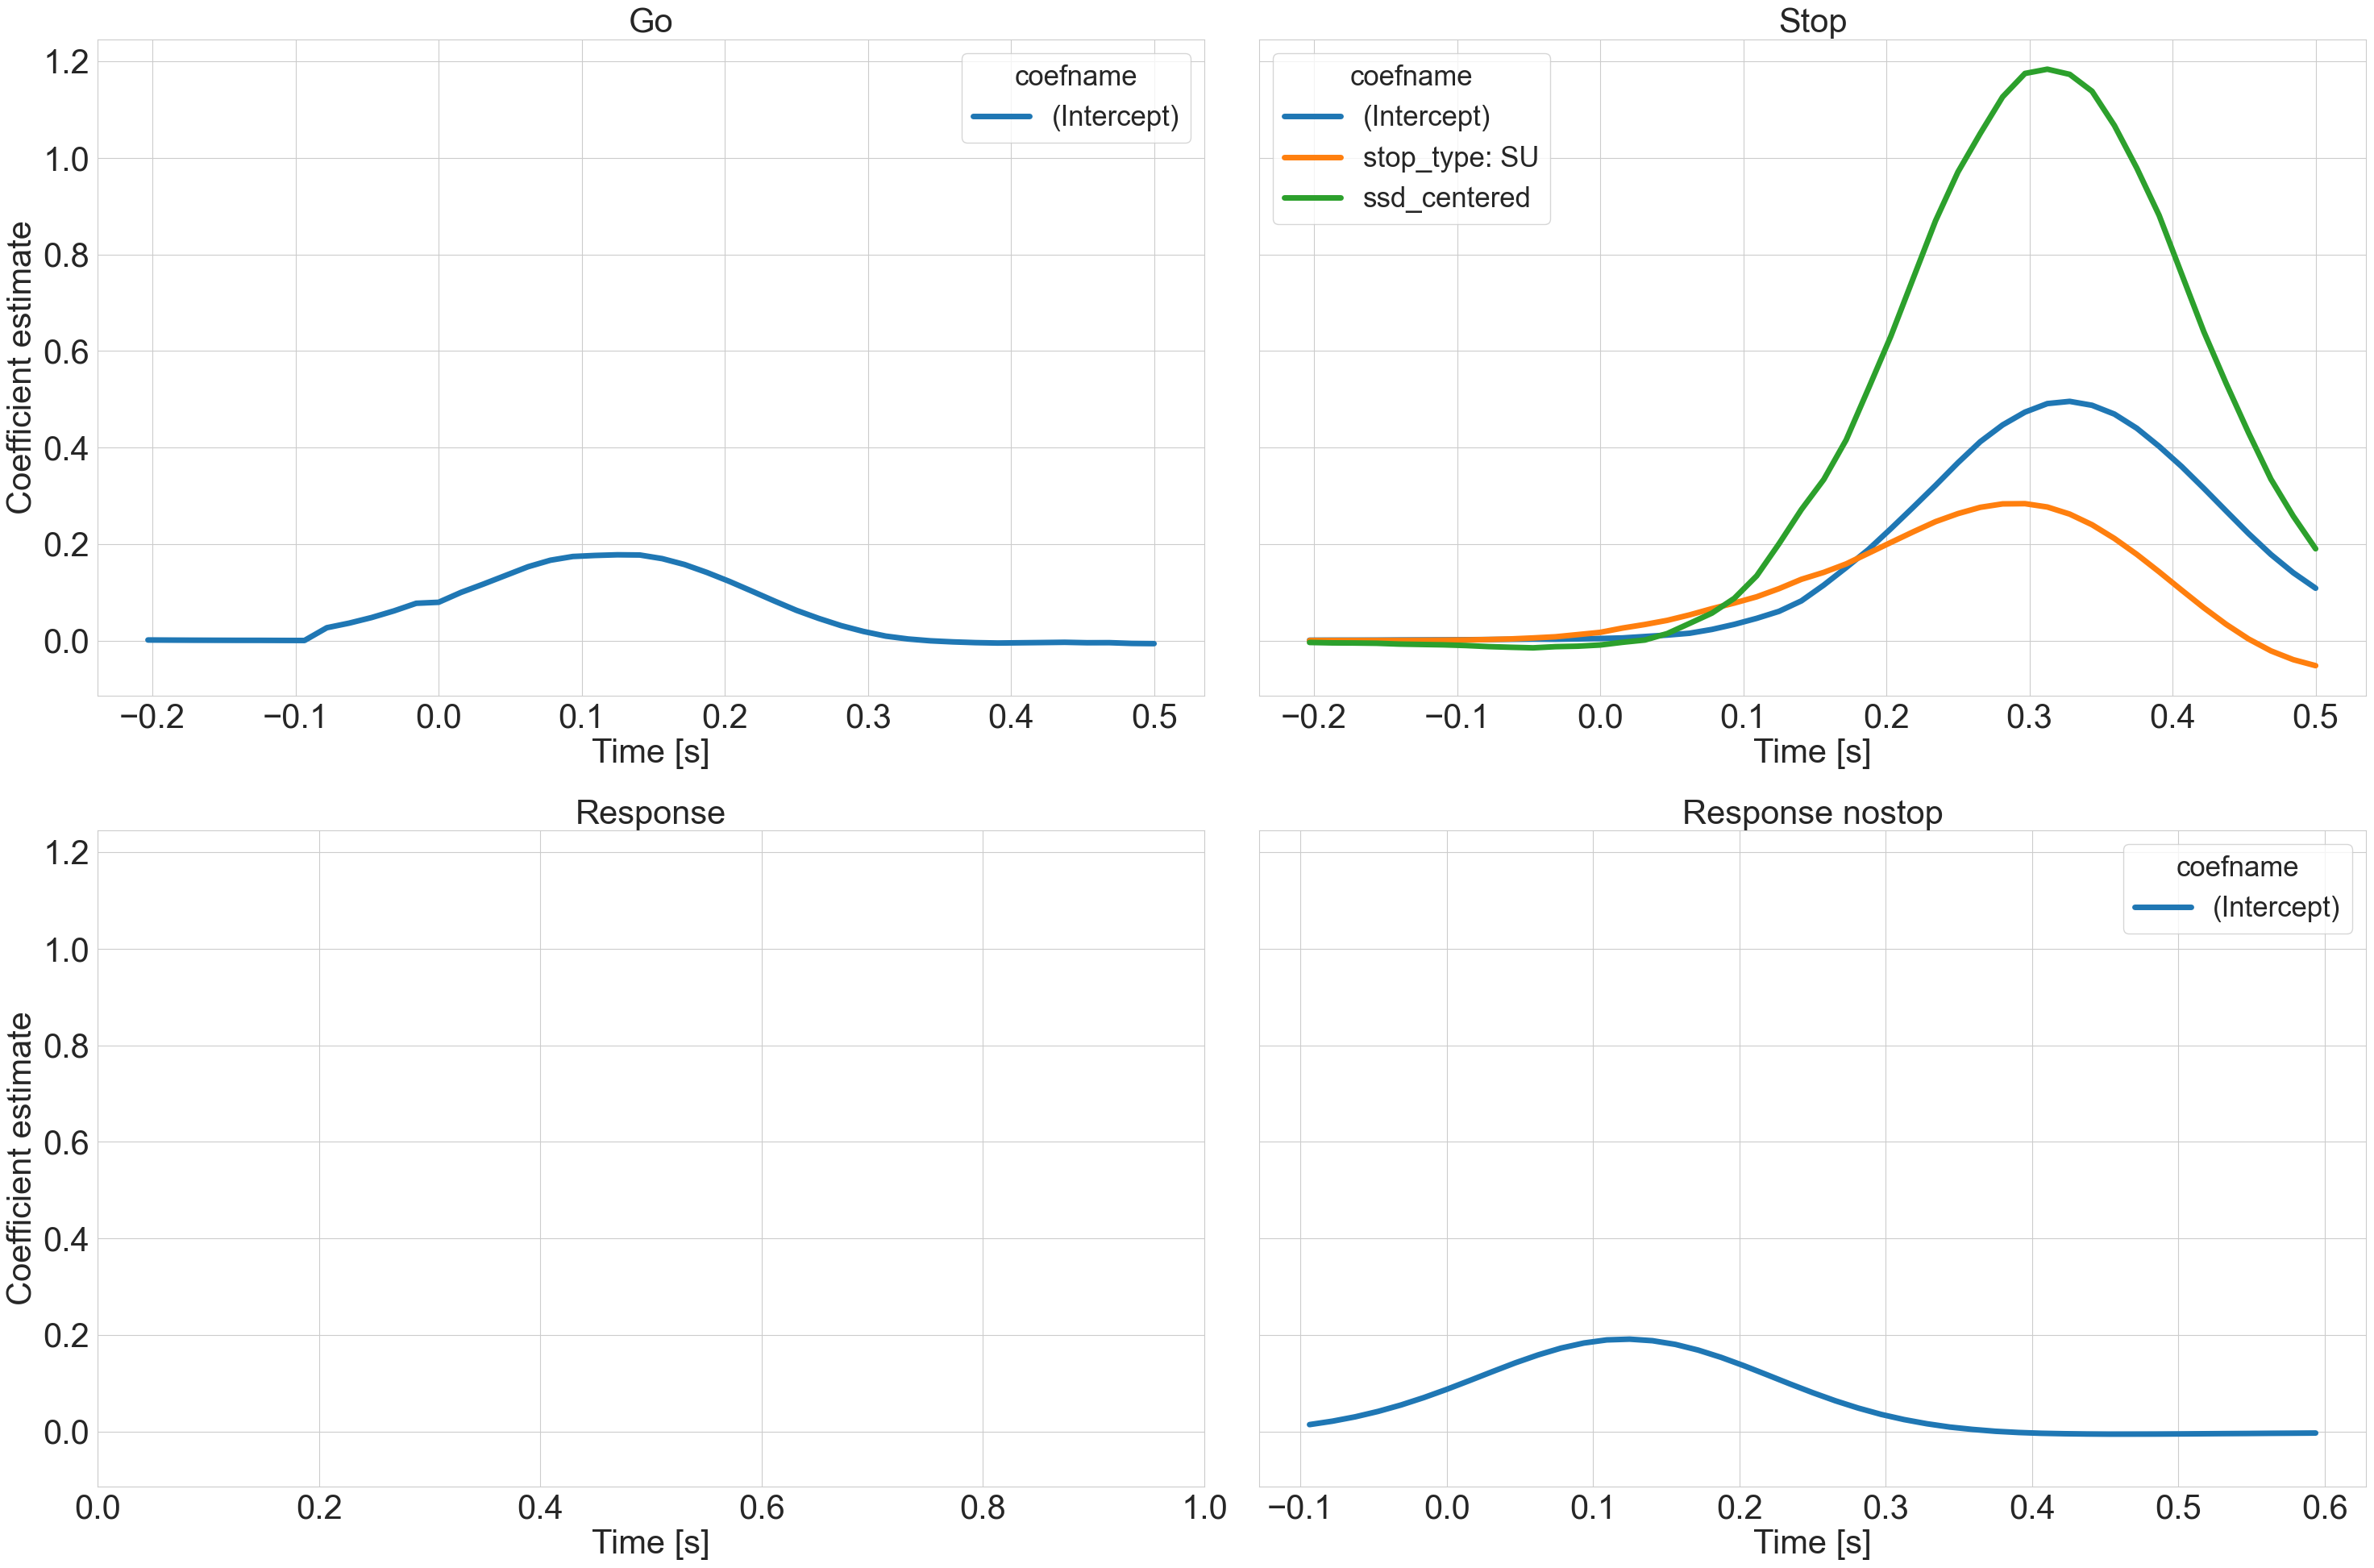

SRI mean: 0.3


<Figure size 640x480 with 0 Axes>

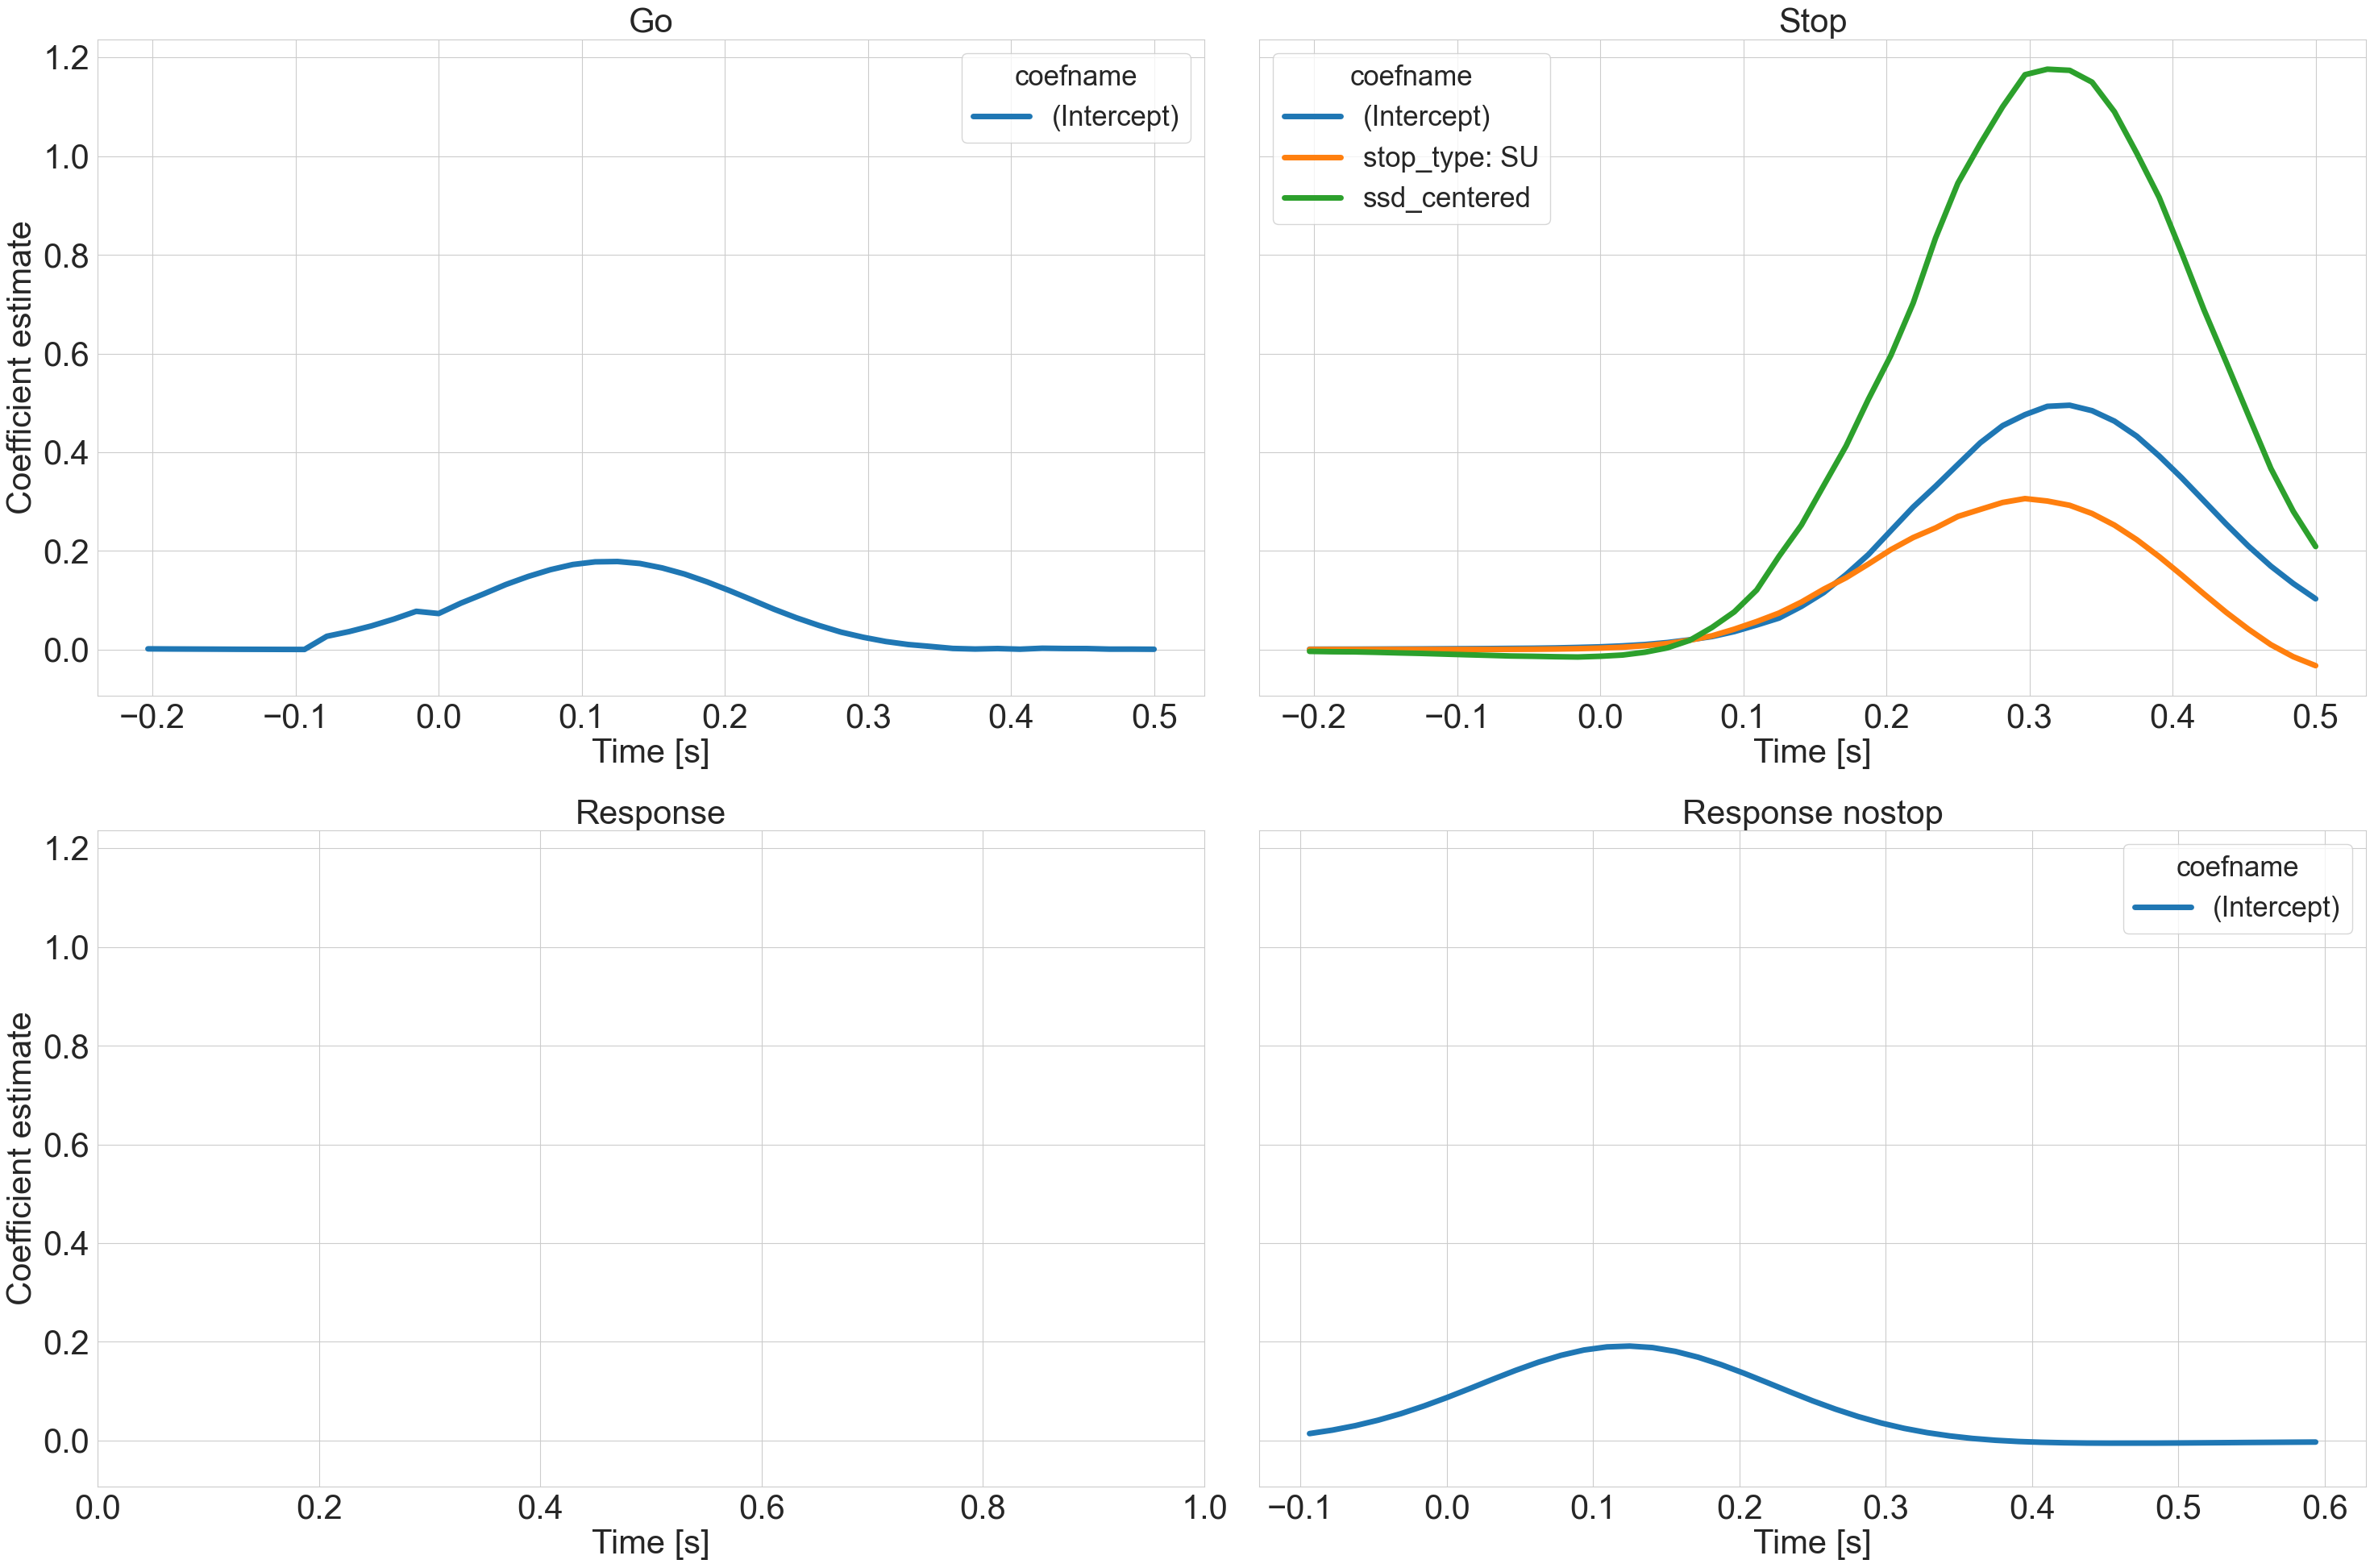

SRI mean: 0.4


<Figure size 640x480 with 0 Axes>

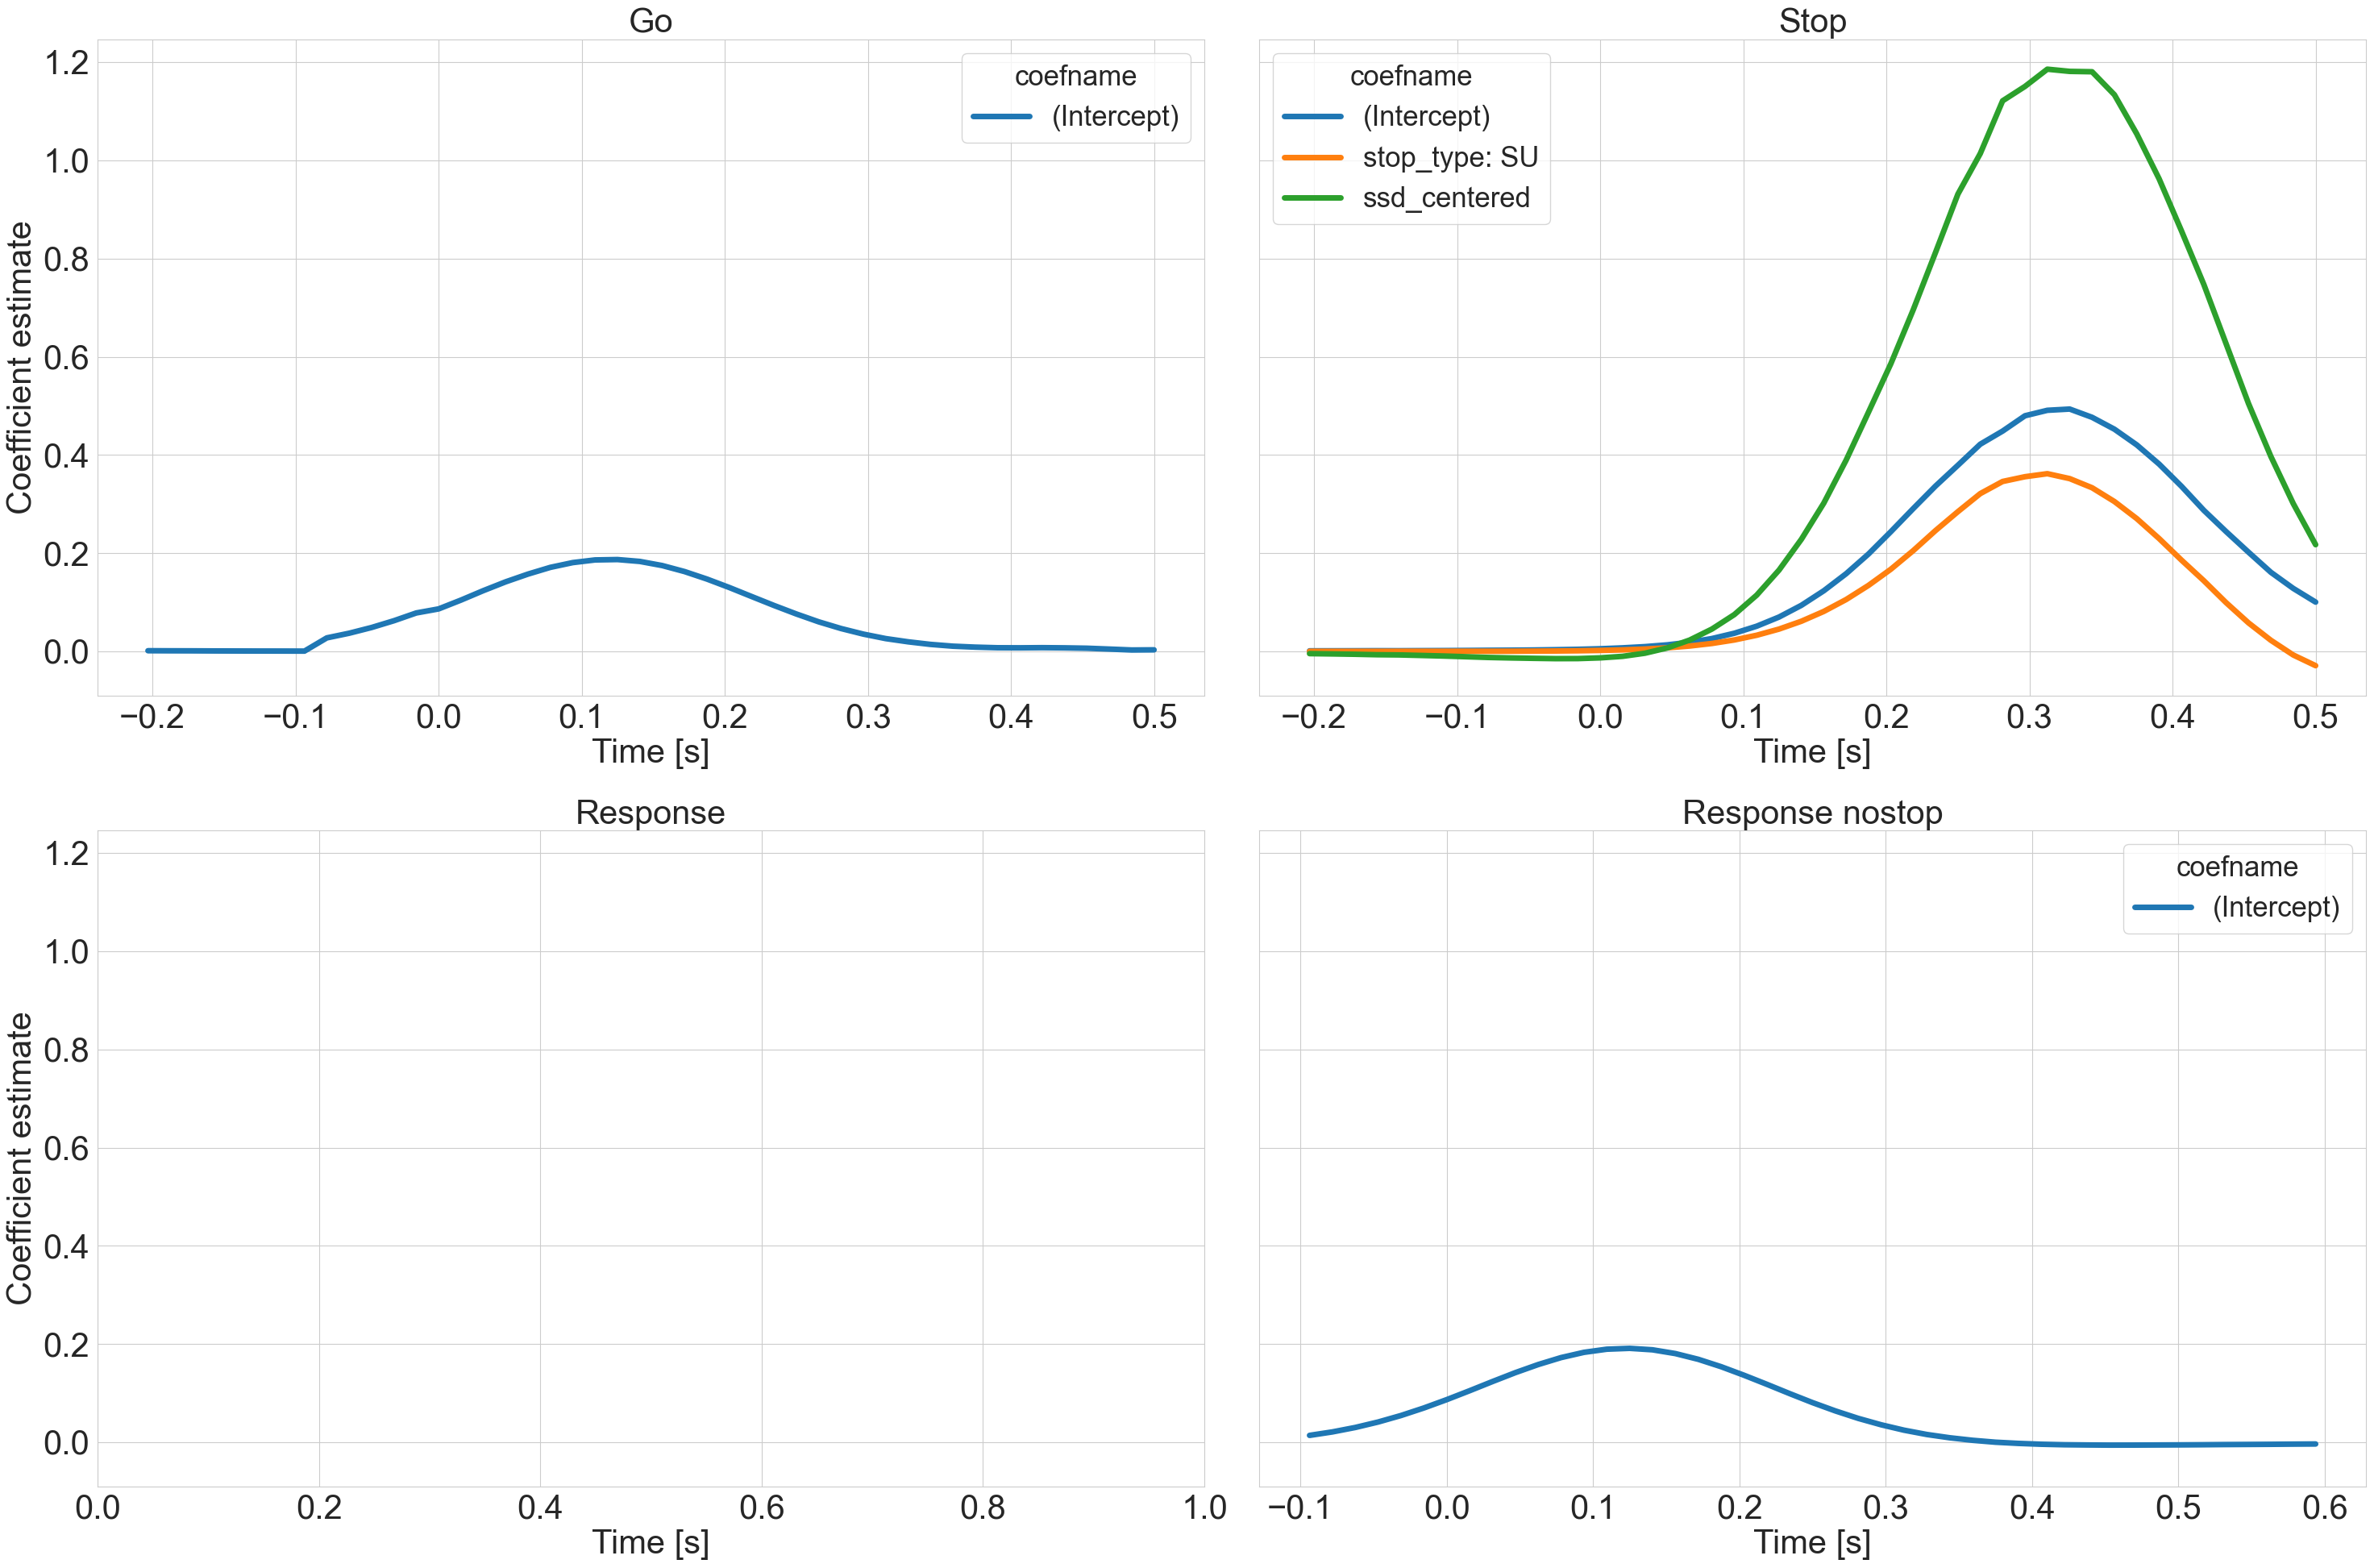

SRI mean: 0.5


<Figure size 640x480 with 0 Axes>

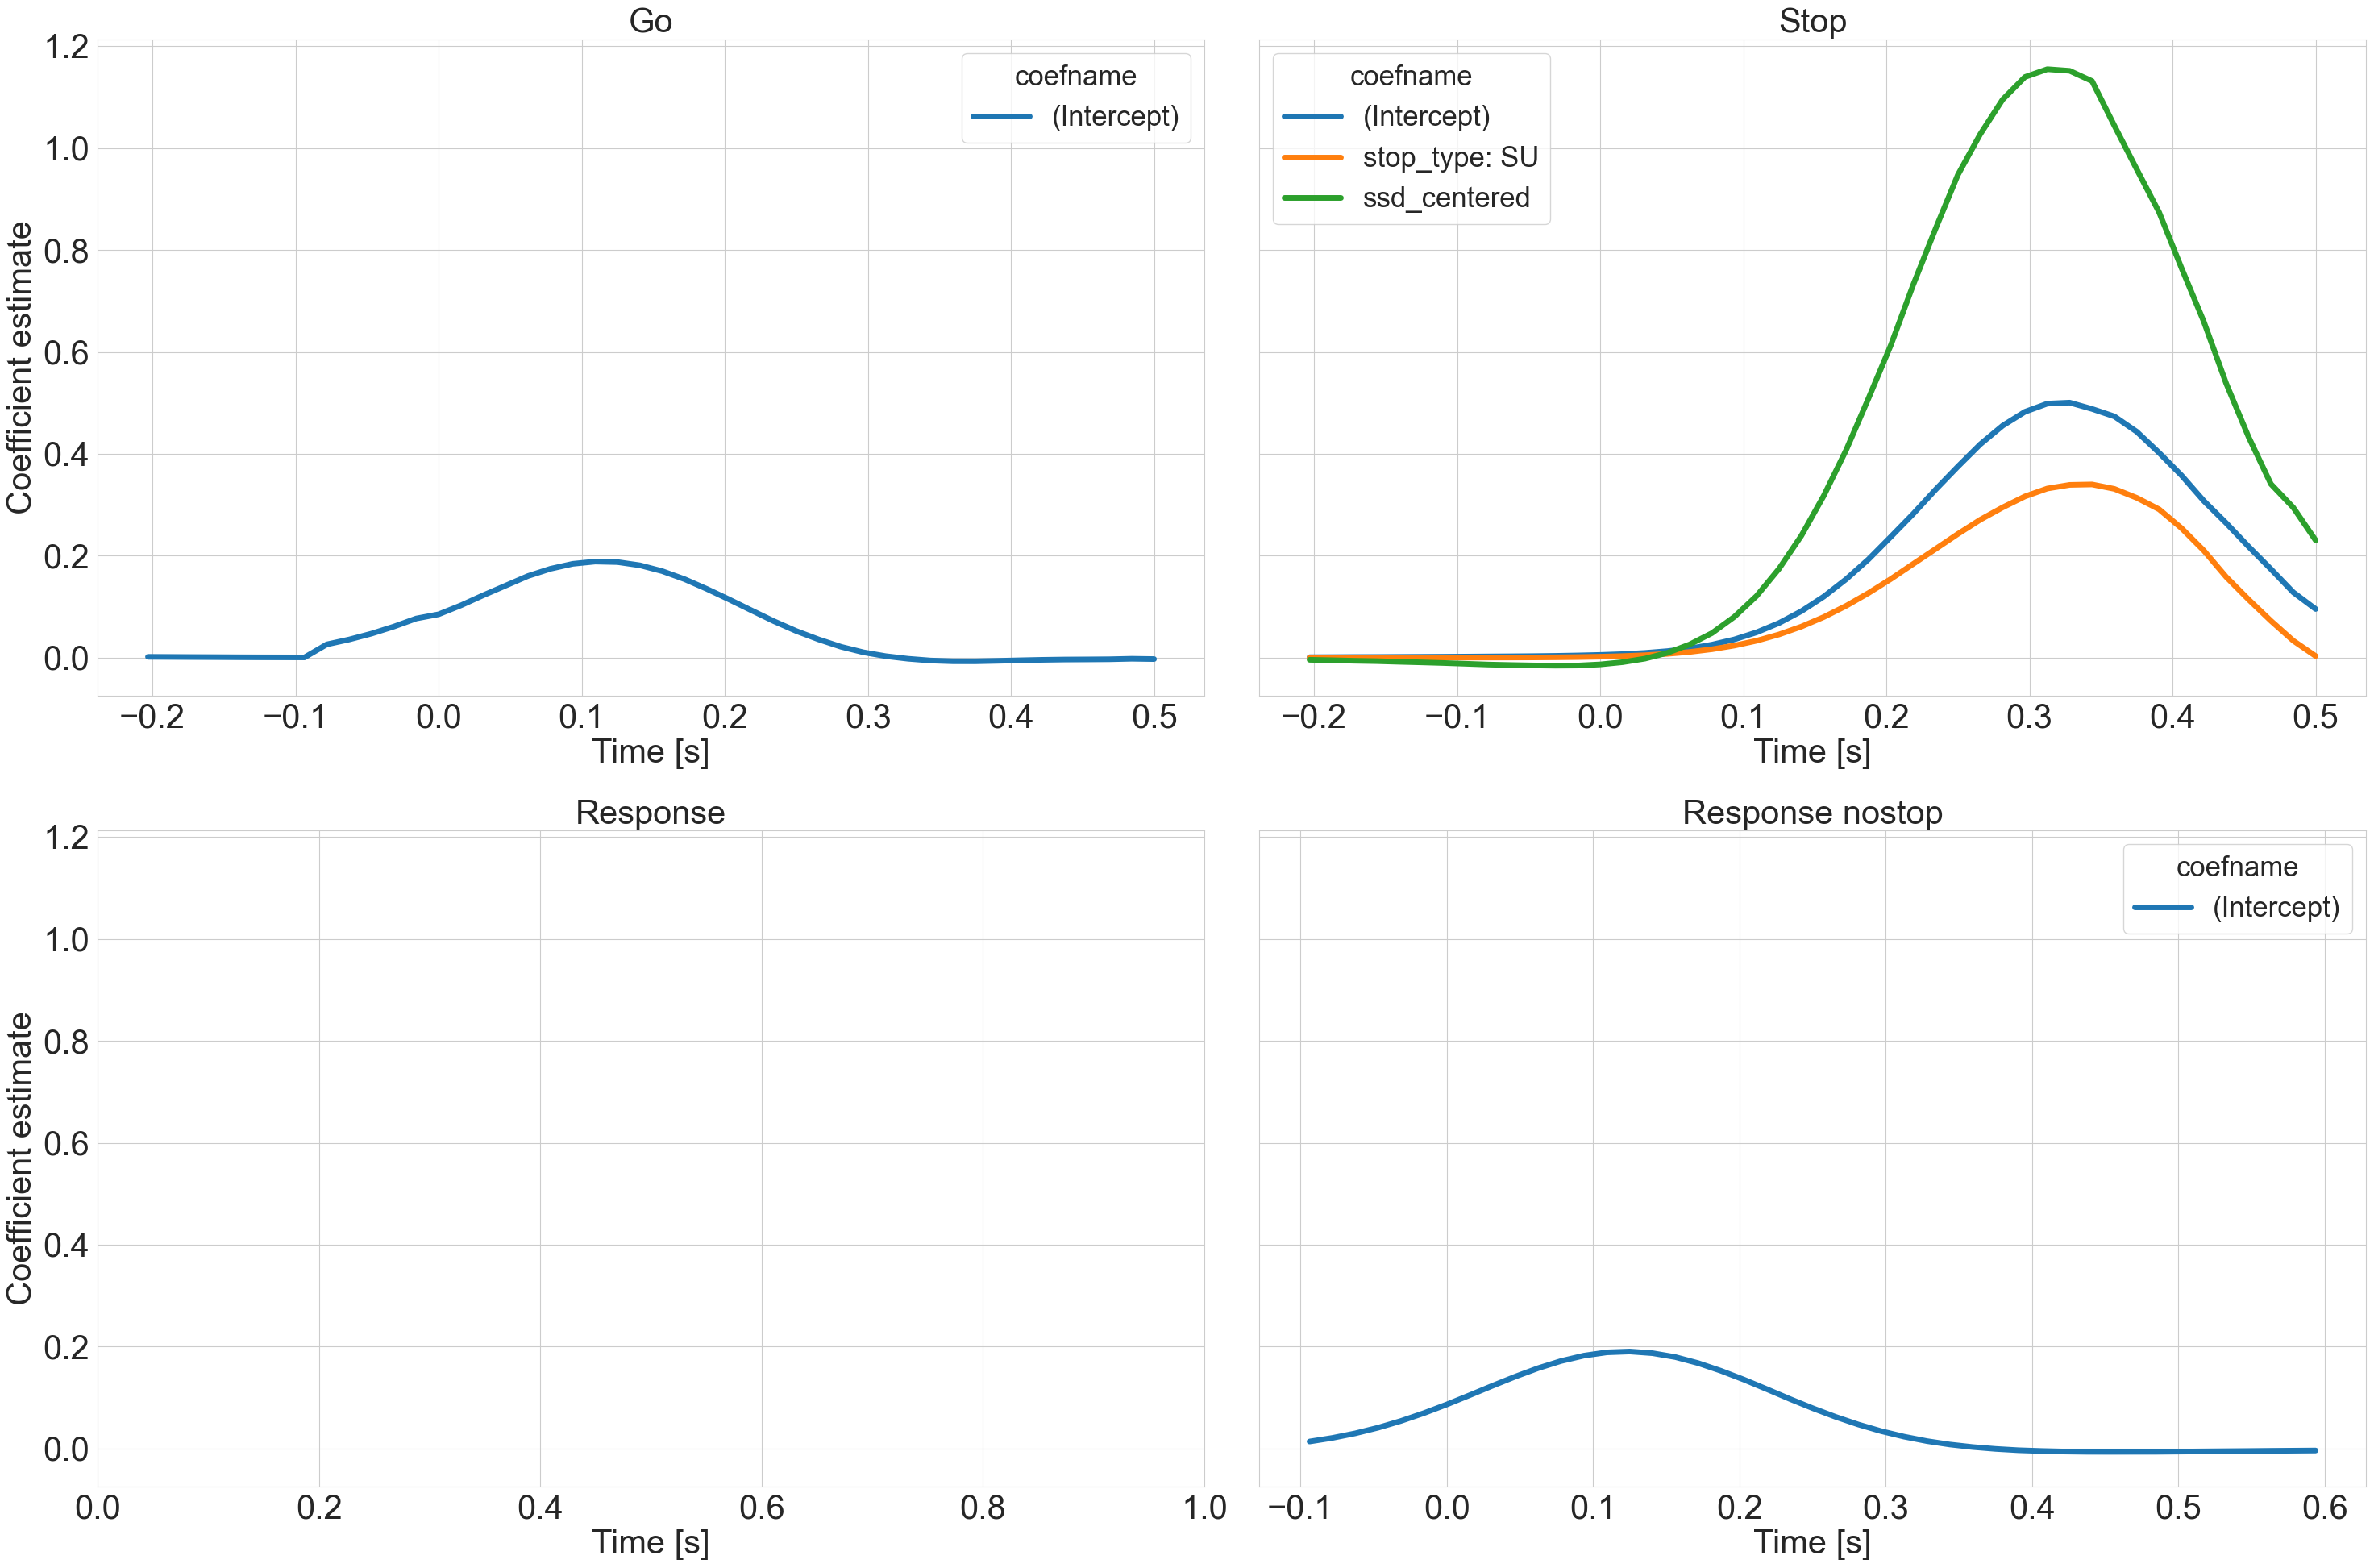

In [63]:
# Parameters
n_trials_per_ssd = 100
distances_C_A = np.arange(0.1, 0.4, 0.05)
sampling_rate = 64
noise_level = 0
duration=1.5


sri_means = [0.2, 0.3, 0.4, 0.5]

for i, sri_mean in enumerate(sri_means):
    config = {
        'go_intercept': 0.2,
        'stop_intercept': 0.5,
        'response_intercept':
            {
                'error': 1,
                'correct_nostop':0.2
            },
        'interactions': {
            'stop x SSD': True,
            'response_error x SSD': True,
            'response_error x SRI': True,
        },
        'probability': {
            'stop': 0.3,
            'error': 0.5,

        },
        'sri': {'loc': sri_mean, 'scale': 0.05}
    }

    # Simulate ERP components with conditions
    erp_trials, data_df = simulations.simulate_erp_components_with_conditions_test(
        n_trials_per_ssd,
        distances_C_A,
        config,
        sampling_rate,
        noise_level,
        duration=duration,
        stop_diff=True,
        remove_ern=False,
        stop_component_offset = .2,
    )

    # create Unfold events dataset
    events_df = simulations.create_events_table(data_df, duration, sampling_rate)

    # perform unfolding
    results =  perform_unfold(events_df, erp_trials)

    # plot results
    print(f'SRI mean: {sri_mean}')
    plt.figure(i)
    unfold_utils2.plot_unfold_results_sst(results)


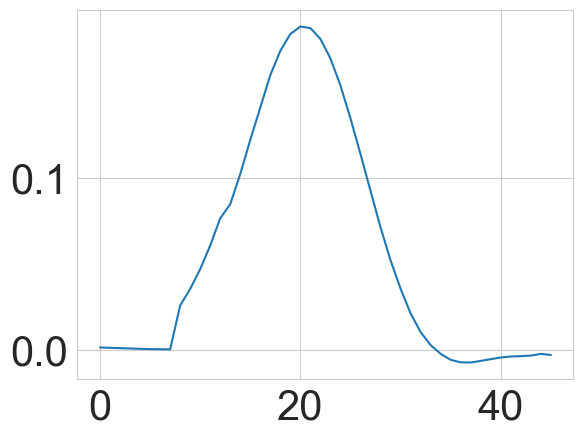

In [70]:
go_signal = results[results['eventname'] == 'go'][['estimate']].to_numpy()
plt.plot(go_signal)

### No ERN

SRI mean: 0.2


<Figure size 640x480 with 0 Axes>

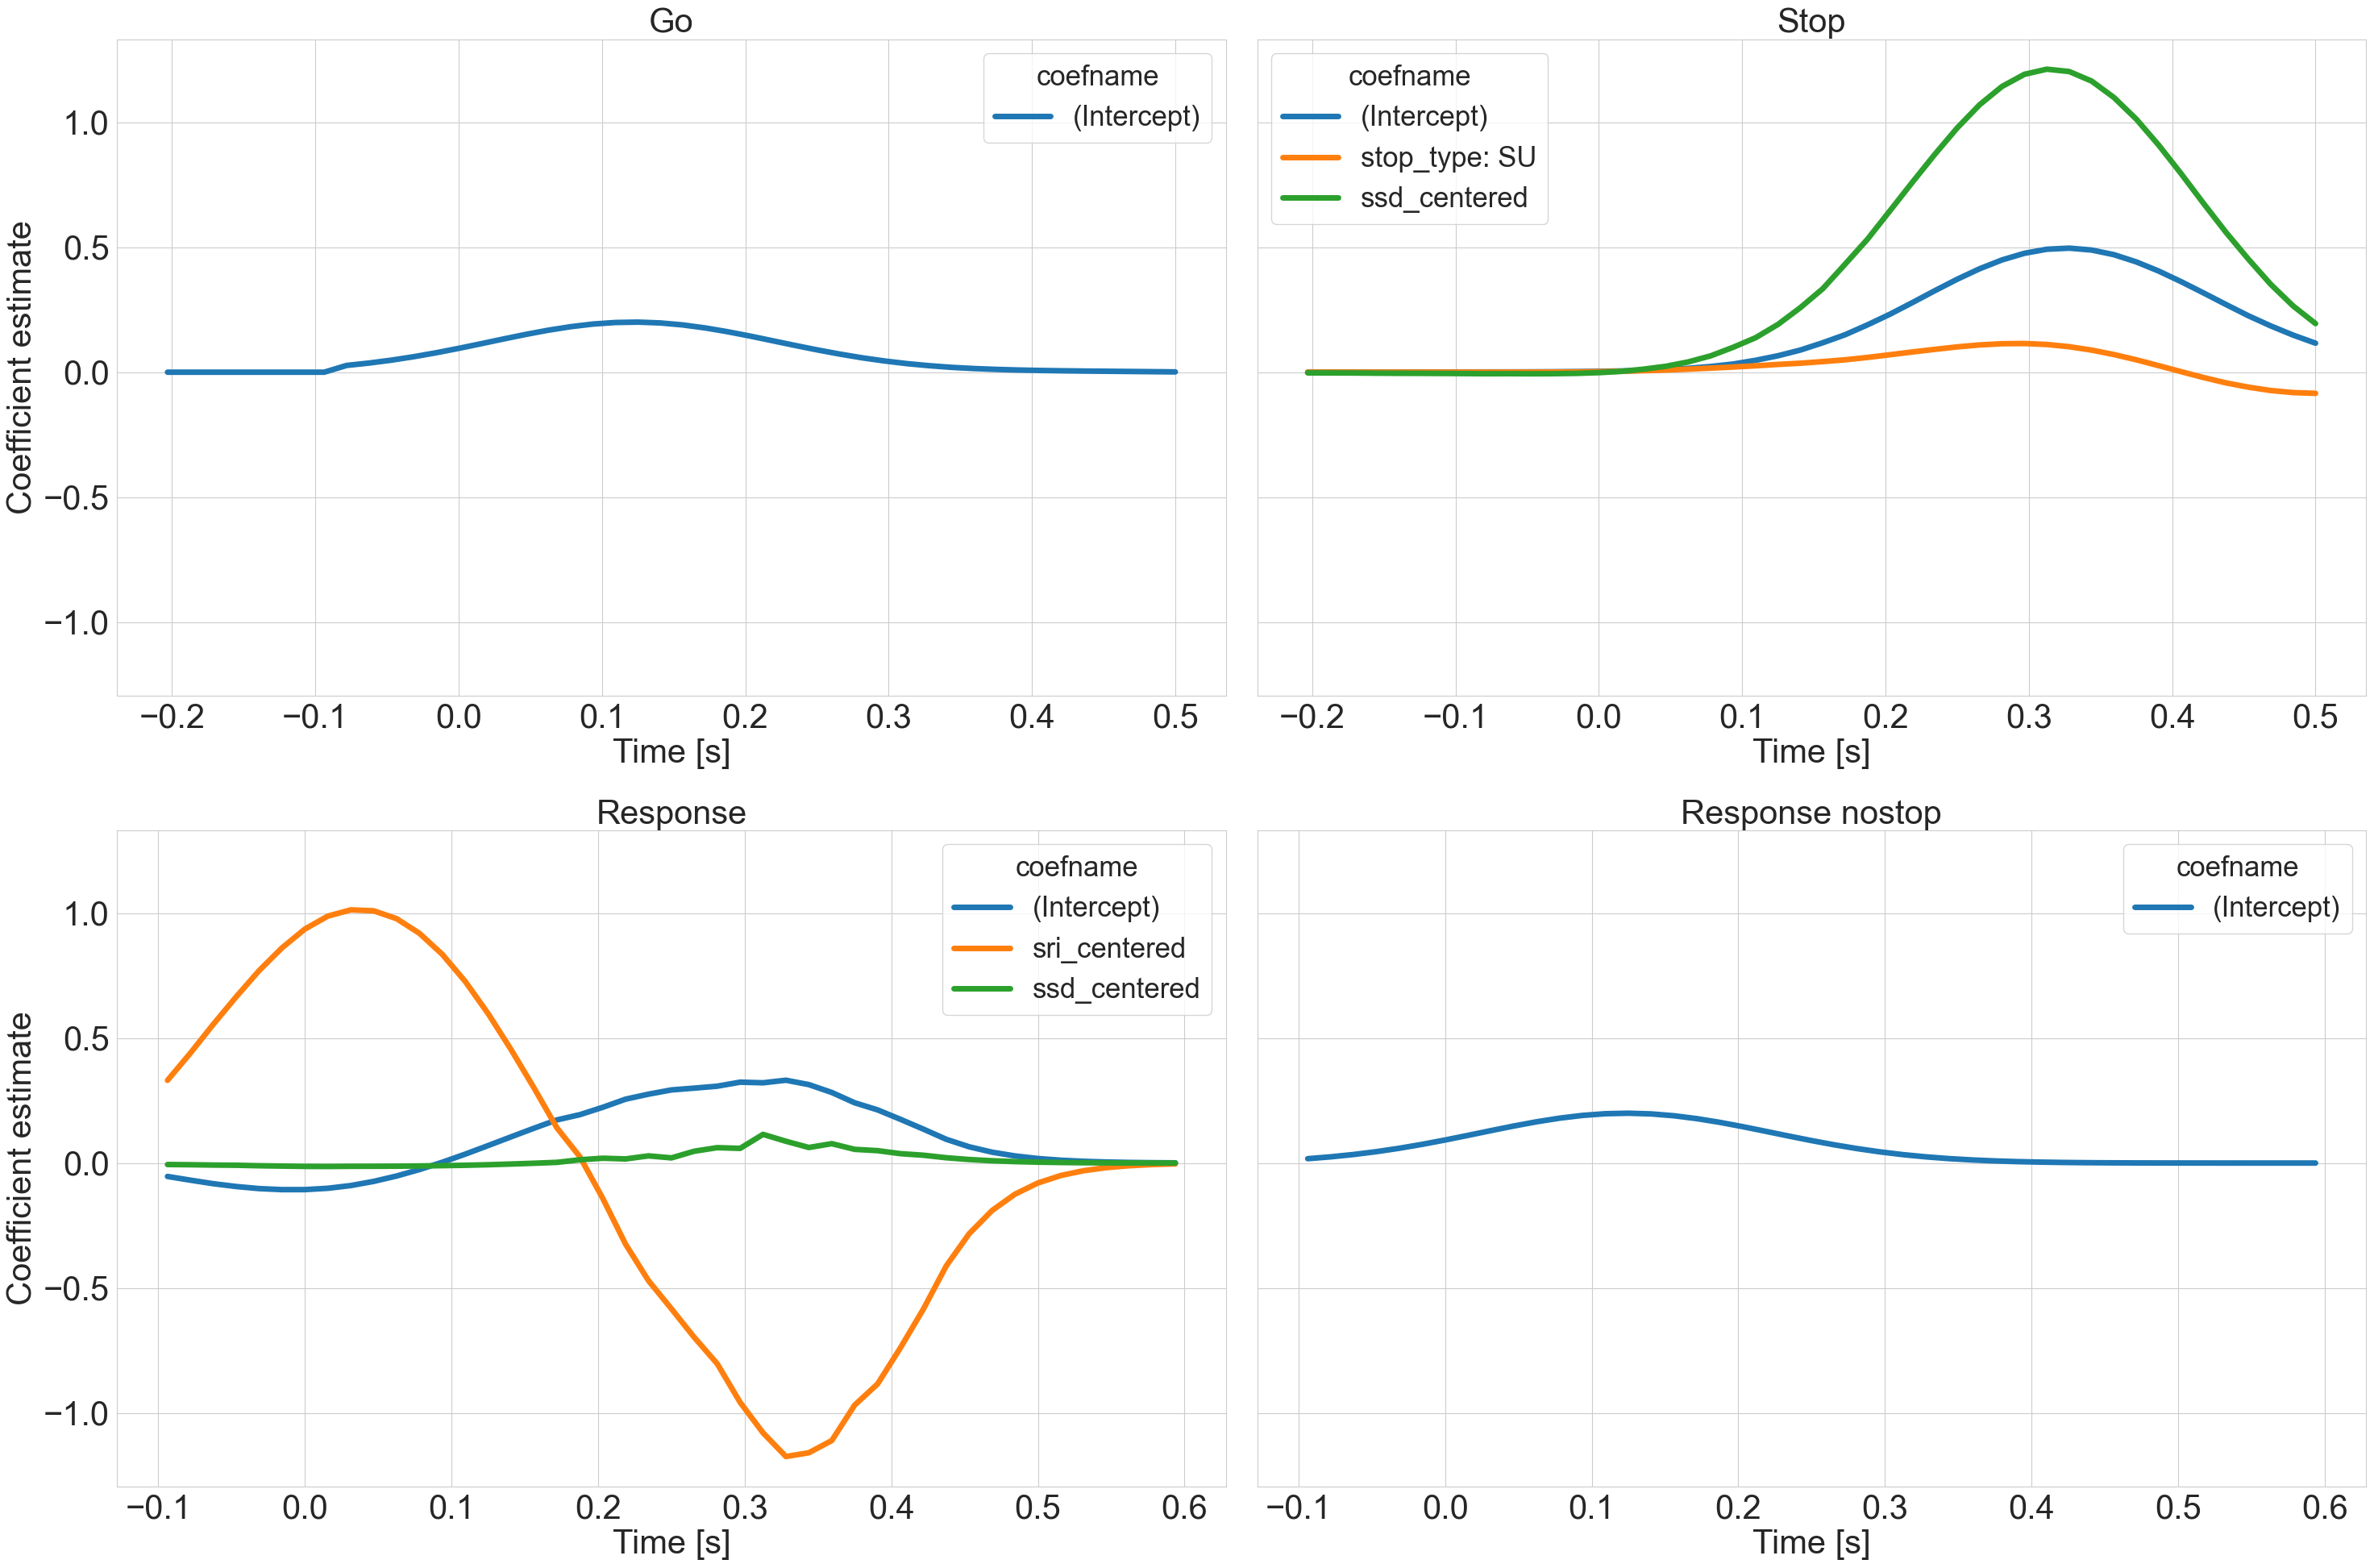

SRI mean: 0.3


<Figure size 640x480 with 0 Axes>

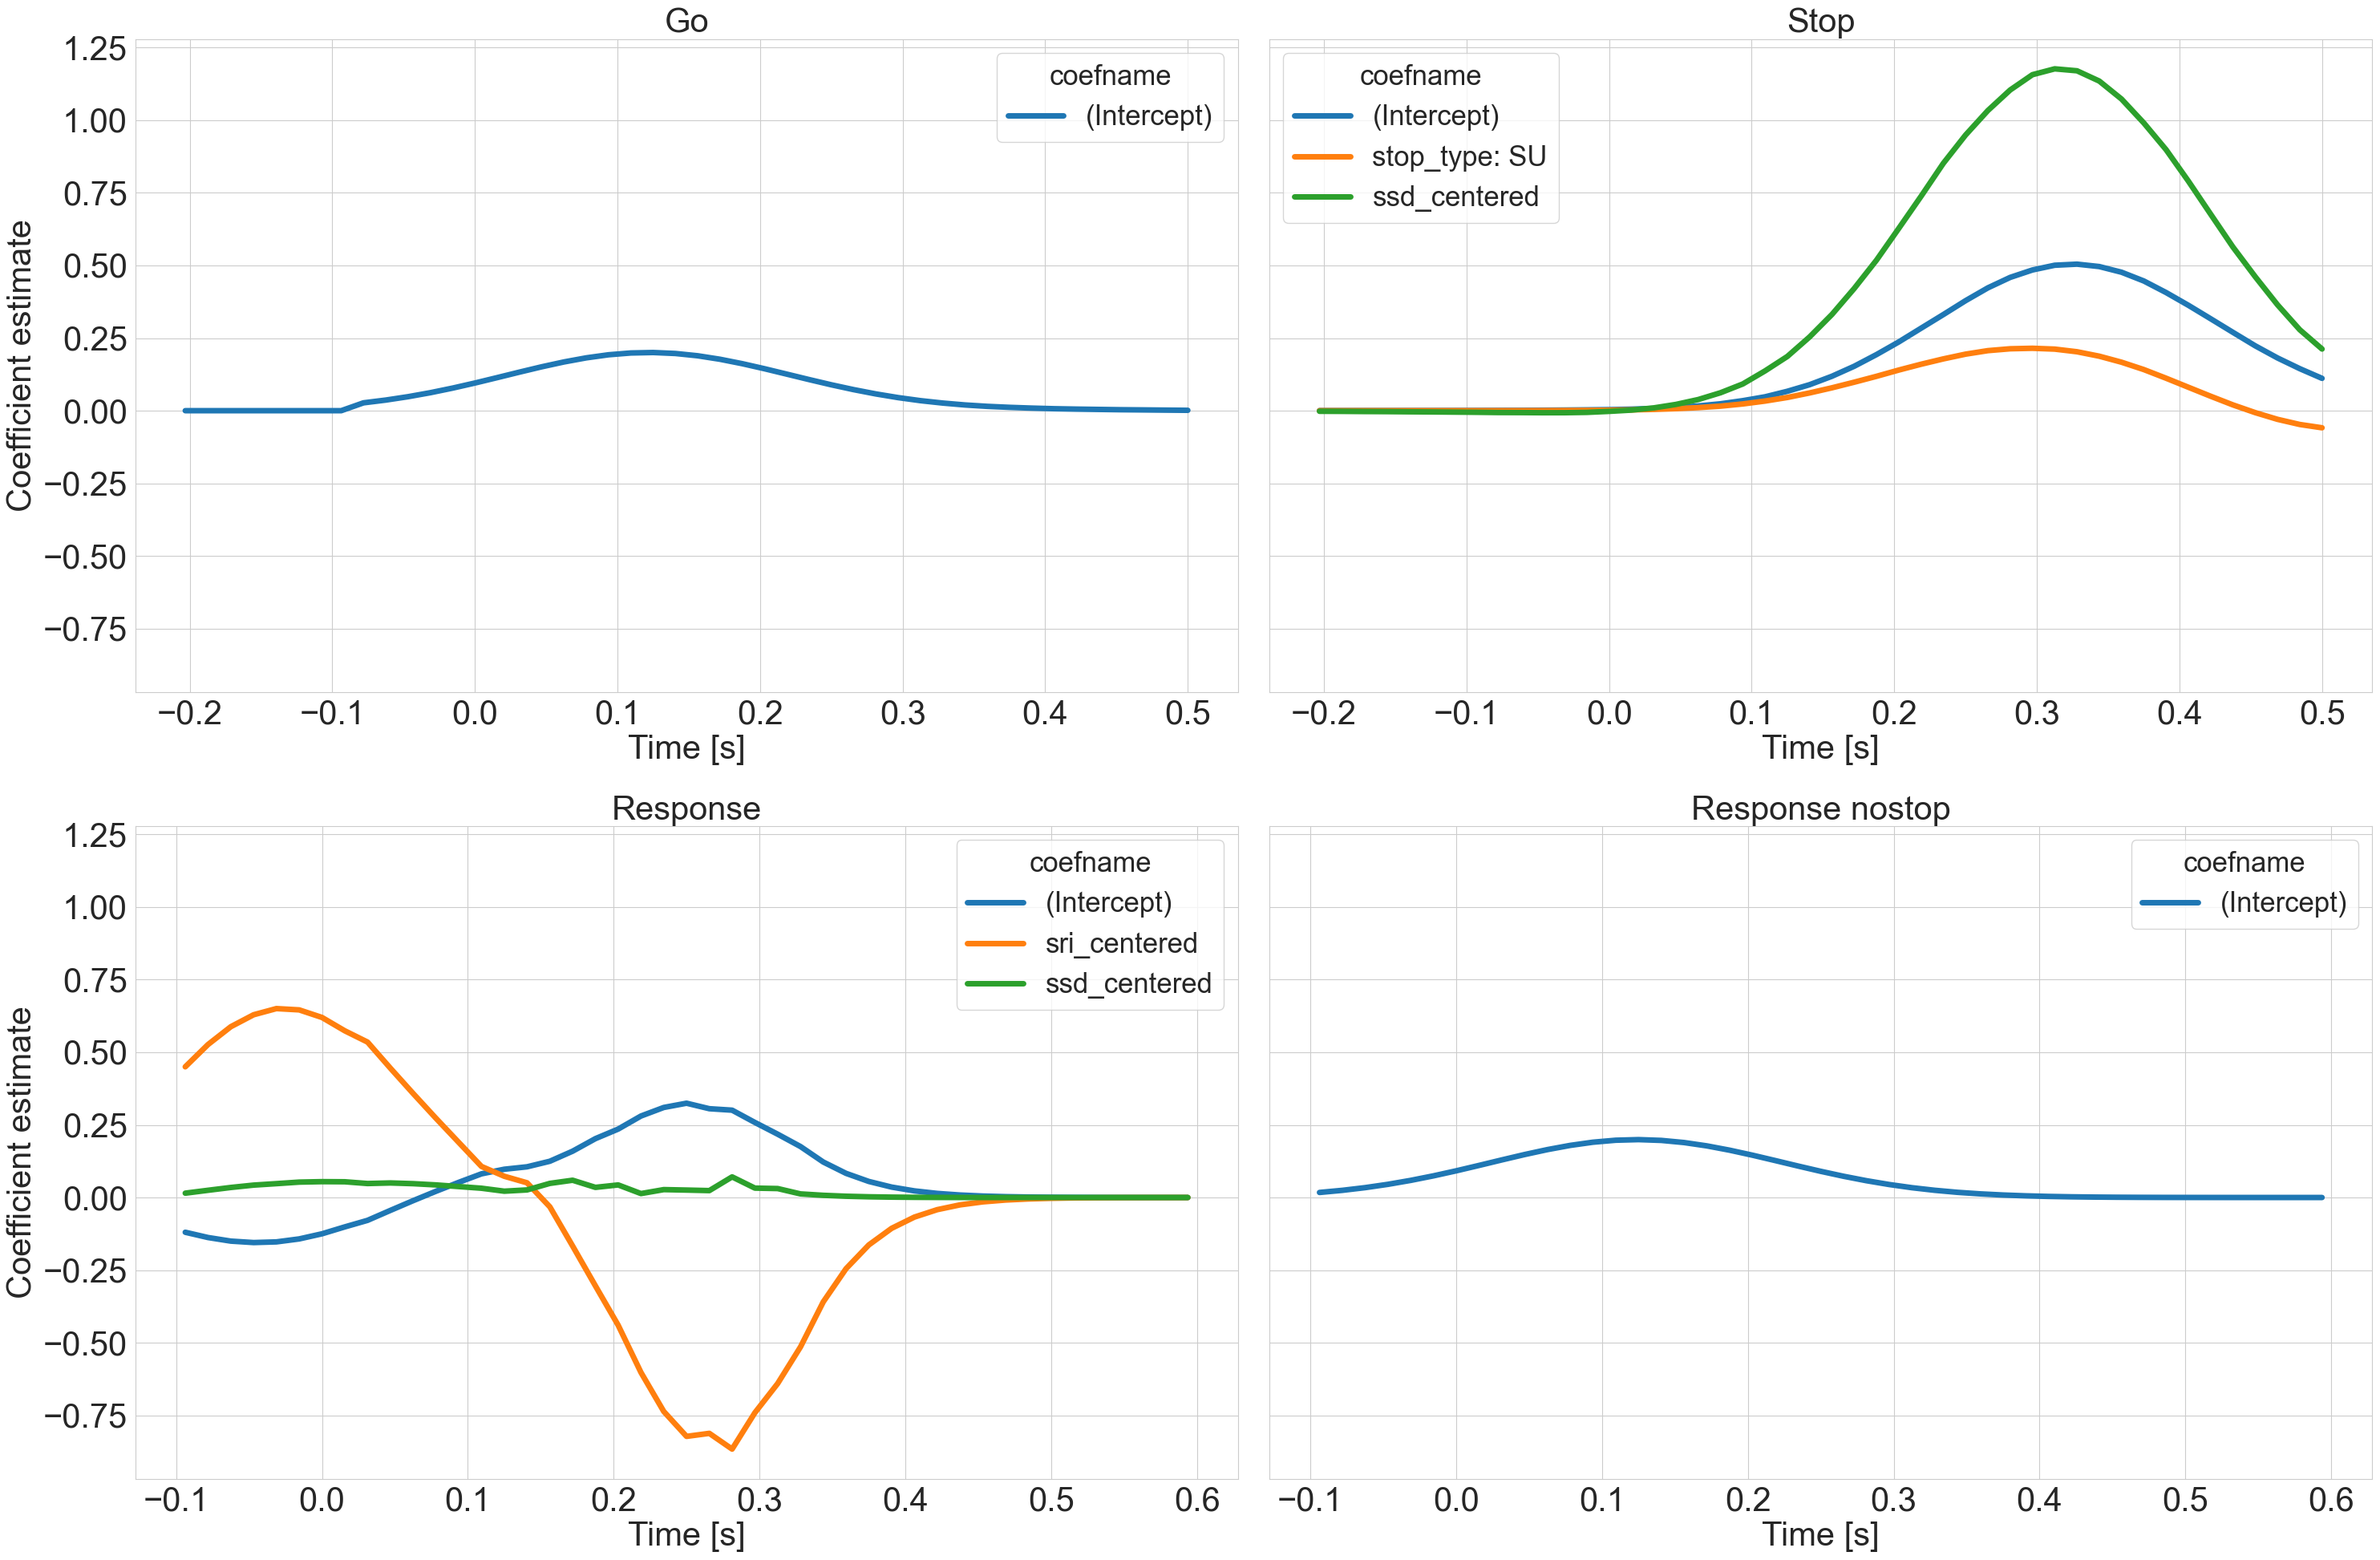

SRI mean: 0.4


<Figure size 640x480 with 0 Axes>

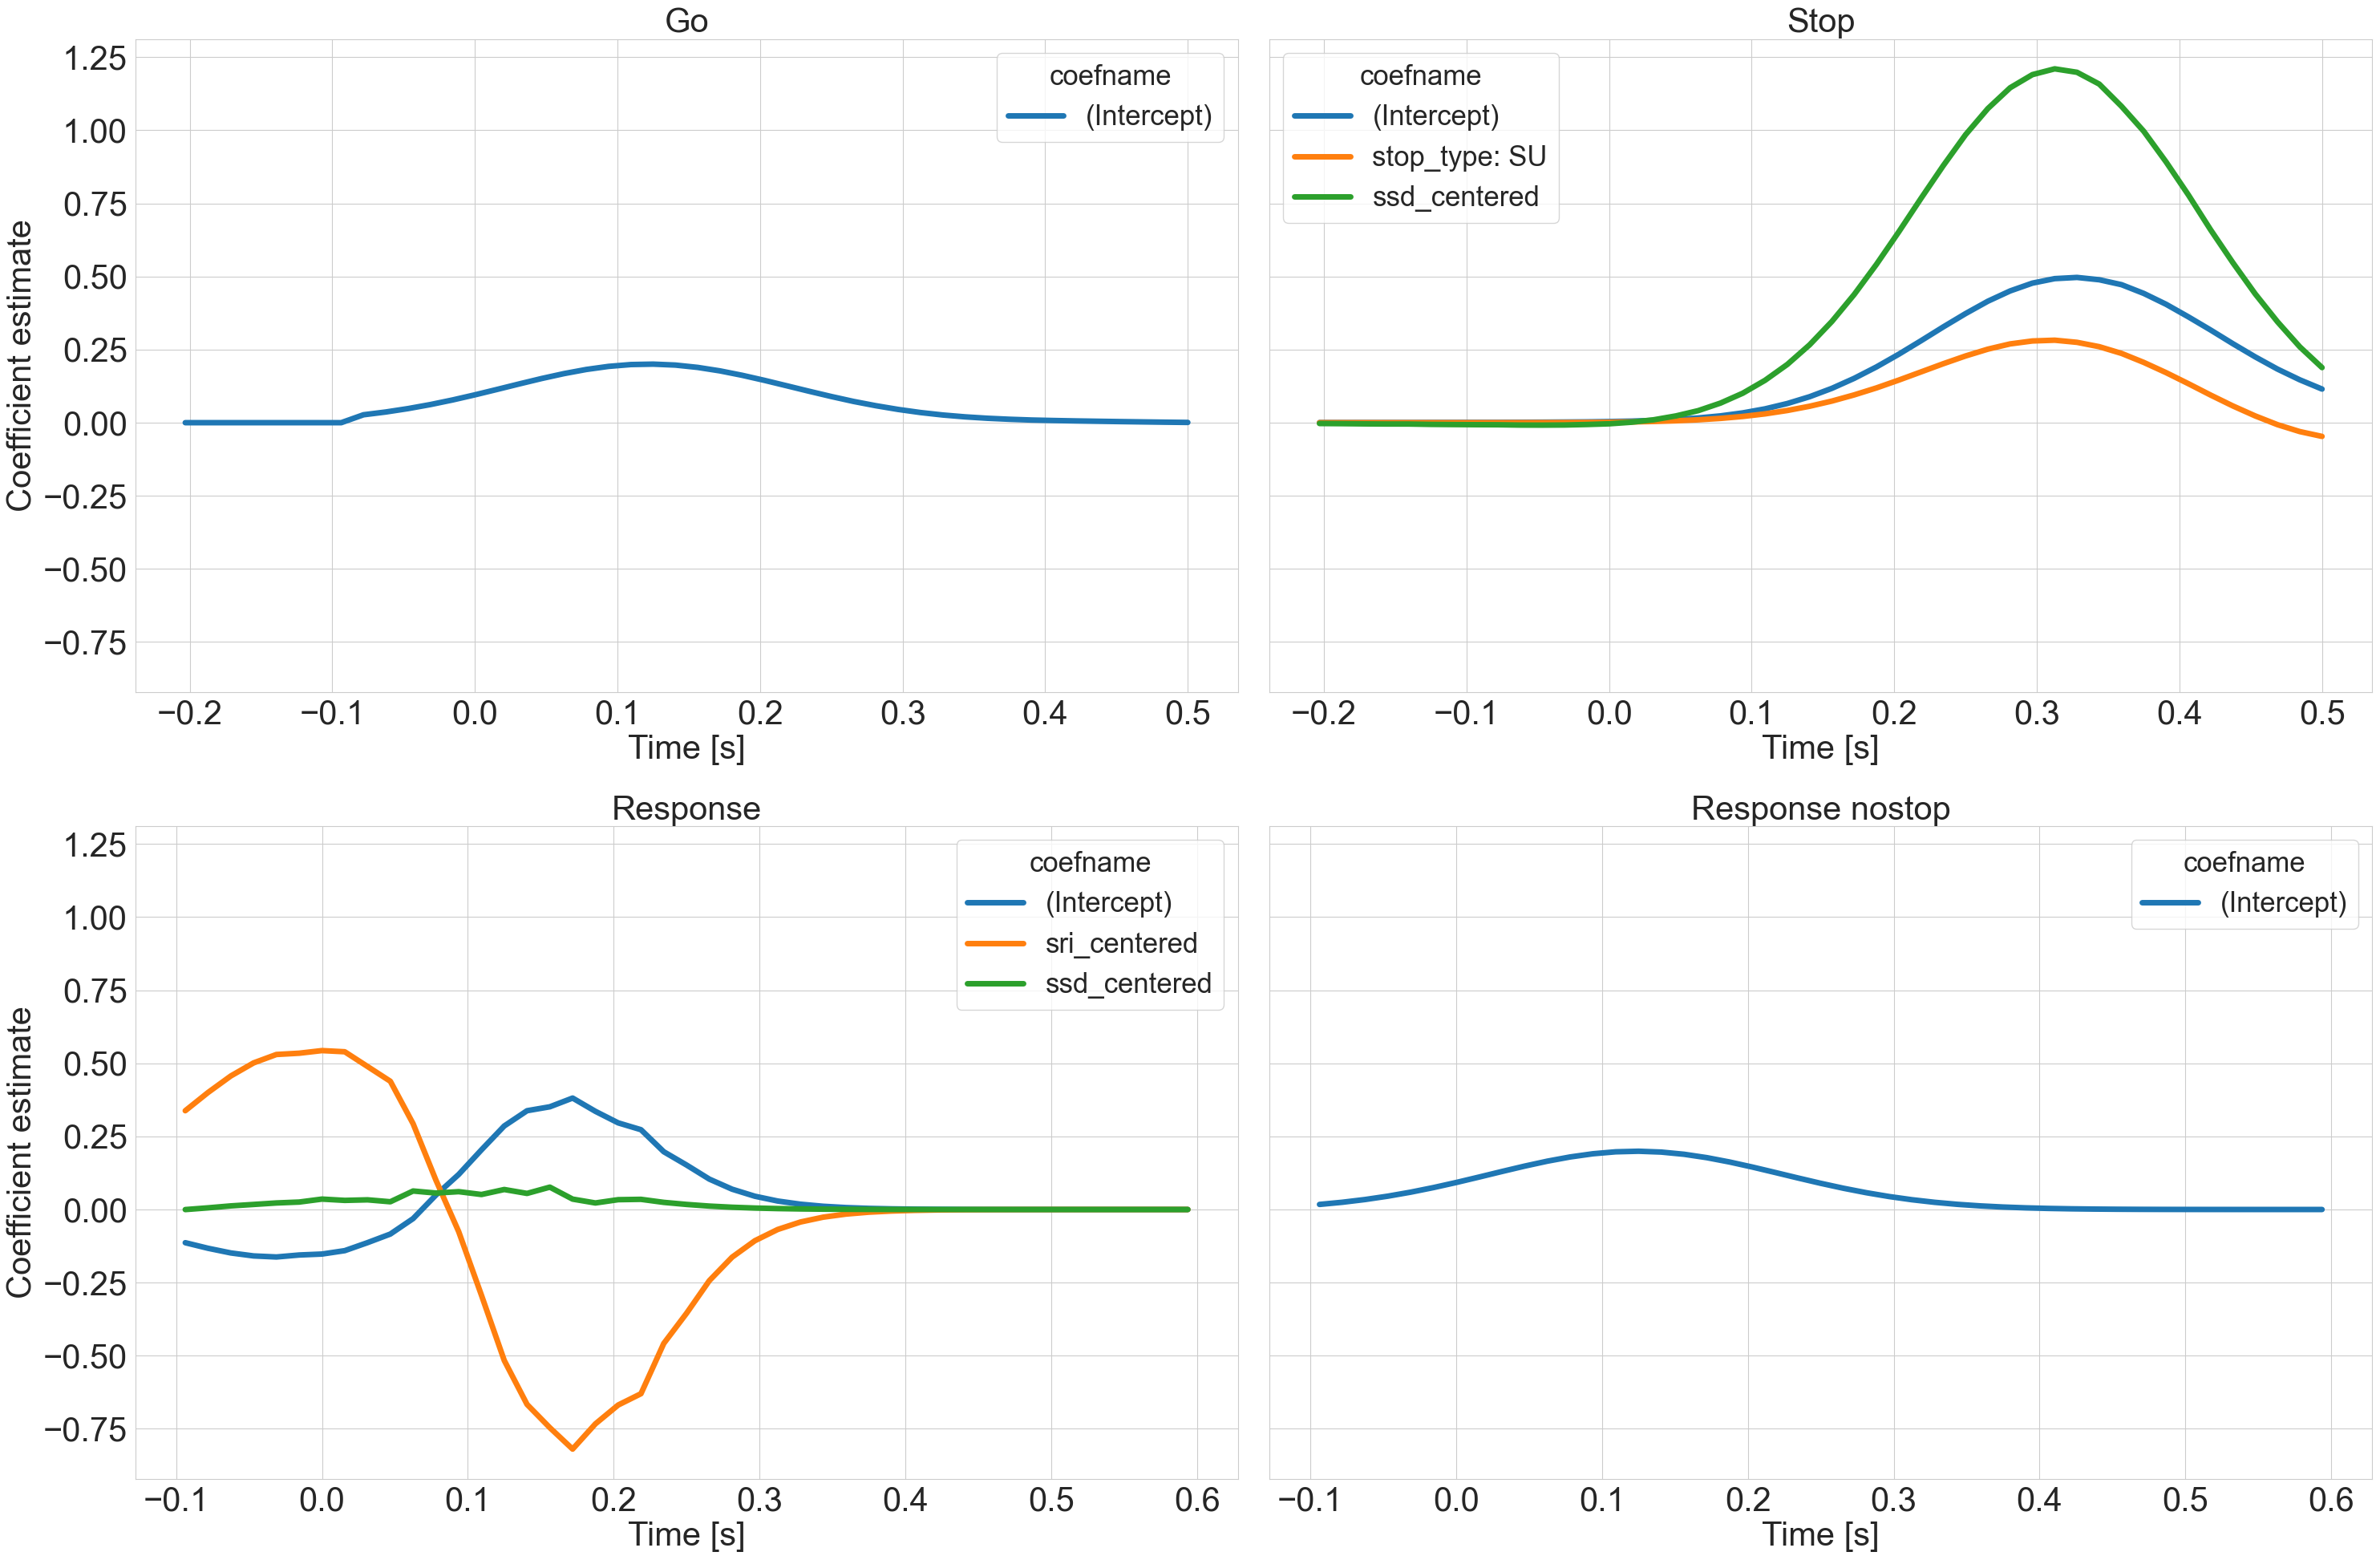

SRI mean: 0.5


<Figure size 640x480 with 0 Axes>

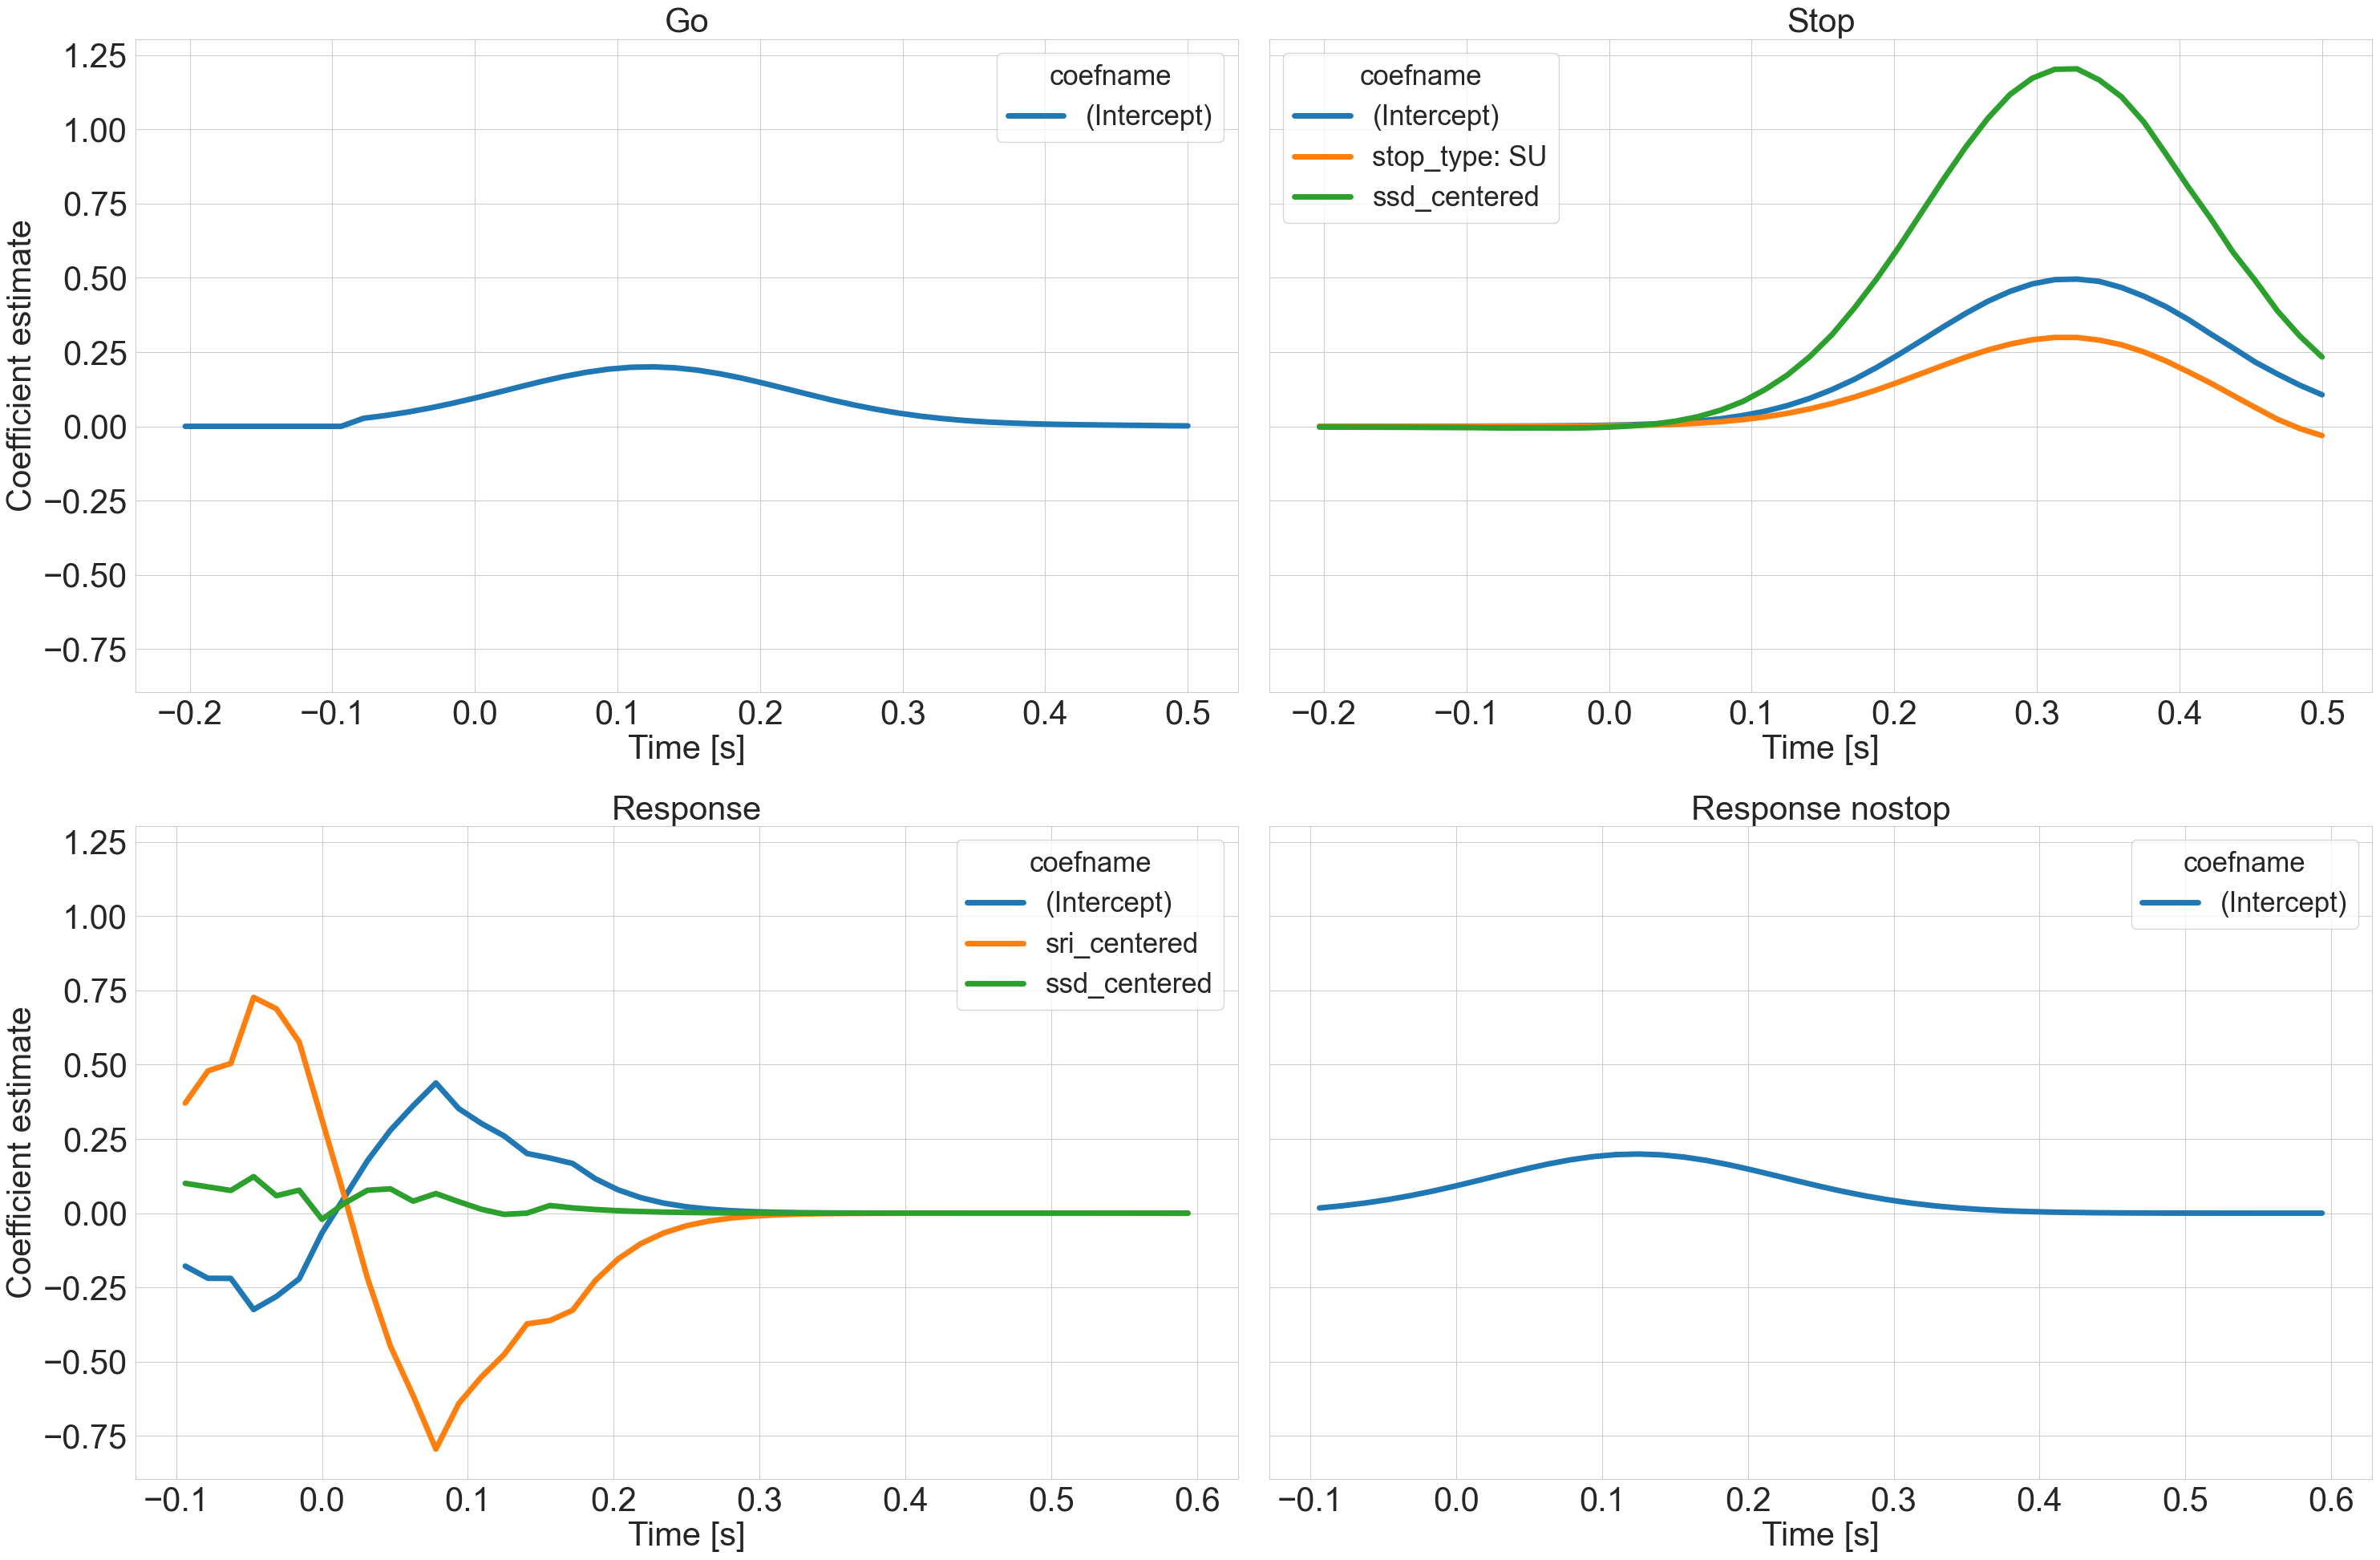

In [5]:
# Parameters
n_trials_per_ssd = 100
distances_C_A = np.arange(0.1, 0.4, 0.05)
sampling_rate = 64
noise_level = 0
duration=1.5


sri_means = [0.2, 0.3, 0.4, 0.5]

for i, sri_mean in enumerate(sri_means):
    config = {
        'go_intercept': 0.2,
        'stop_intercept': 0.5,
        'response_intercept':
            {
                'error': 1,
                'correct_nostop':0.2
            },
        'interactions': {
            'stop x SSD': True,
            'response_error x SSD': True,
            'response_error x SRI': True,
        },
        'probability': {
            'stop': 0.3,
            'error': 0.5,

        },
        'sri': {'loc': sri_mean, 'scale': 0.05}
    }

    # Simulate ERP components with conditions
    erp_trials, data_df = simulations.simulate_erp_components_with_conditions_test(
        n_trials_per_ssd,
        distances_C_A,
        config,
        sampling_rate,
        noise_level,
        duration=duration,
        stop_diff=True,
        remove_ern=True,
        stop_component_offset = .2,
    )

    # create Unfold events dataset
    events_df = simulations.create_events_table(data_df, duration, sampling_rate)

    # perform unfolding
    results = unfold_utils.perform_unfold(events_df, erp_trials)

    # plot results
    print(f'SRI mean: {sri_mean}')
    plt.figure(i)
    unfold_utils.plot_unfold_results_sst(results)


SRI mean: 0.2


<Figure size 640x480 with 0 Axes>

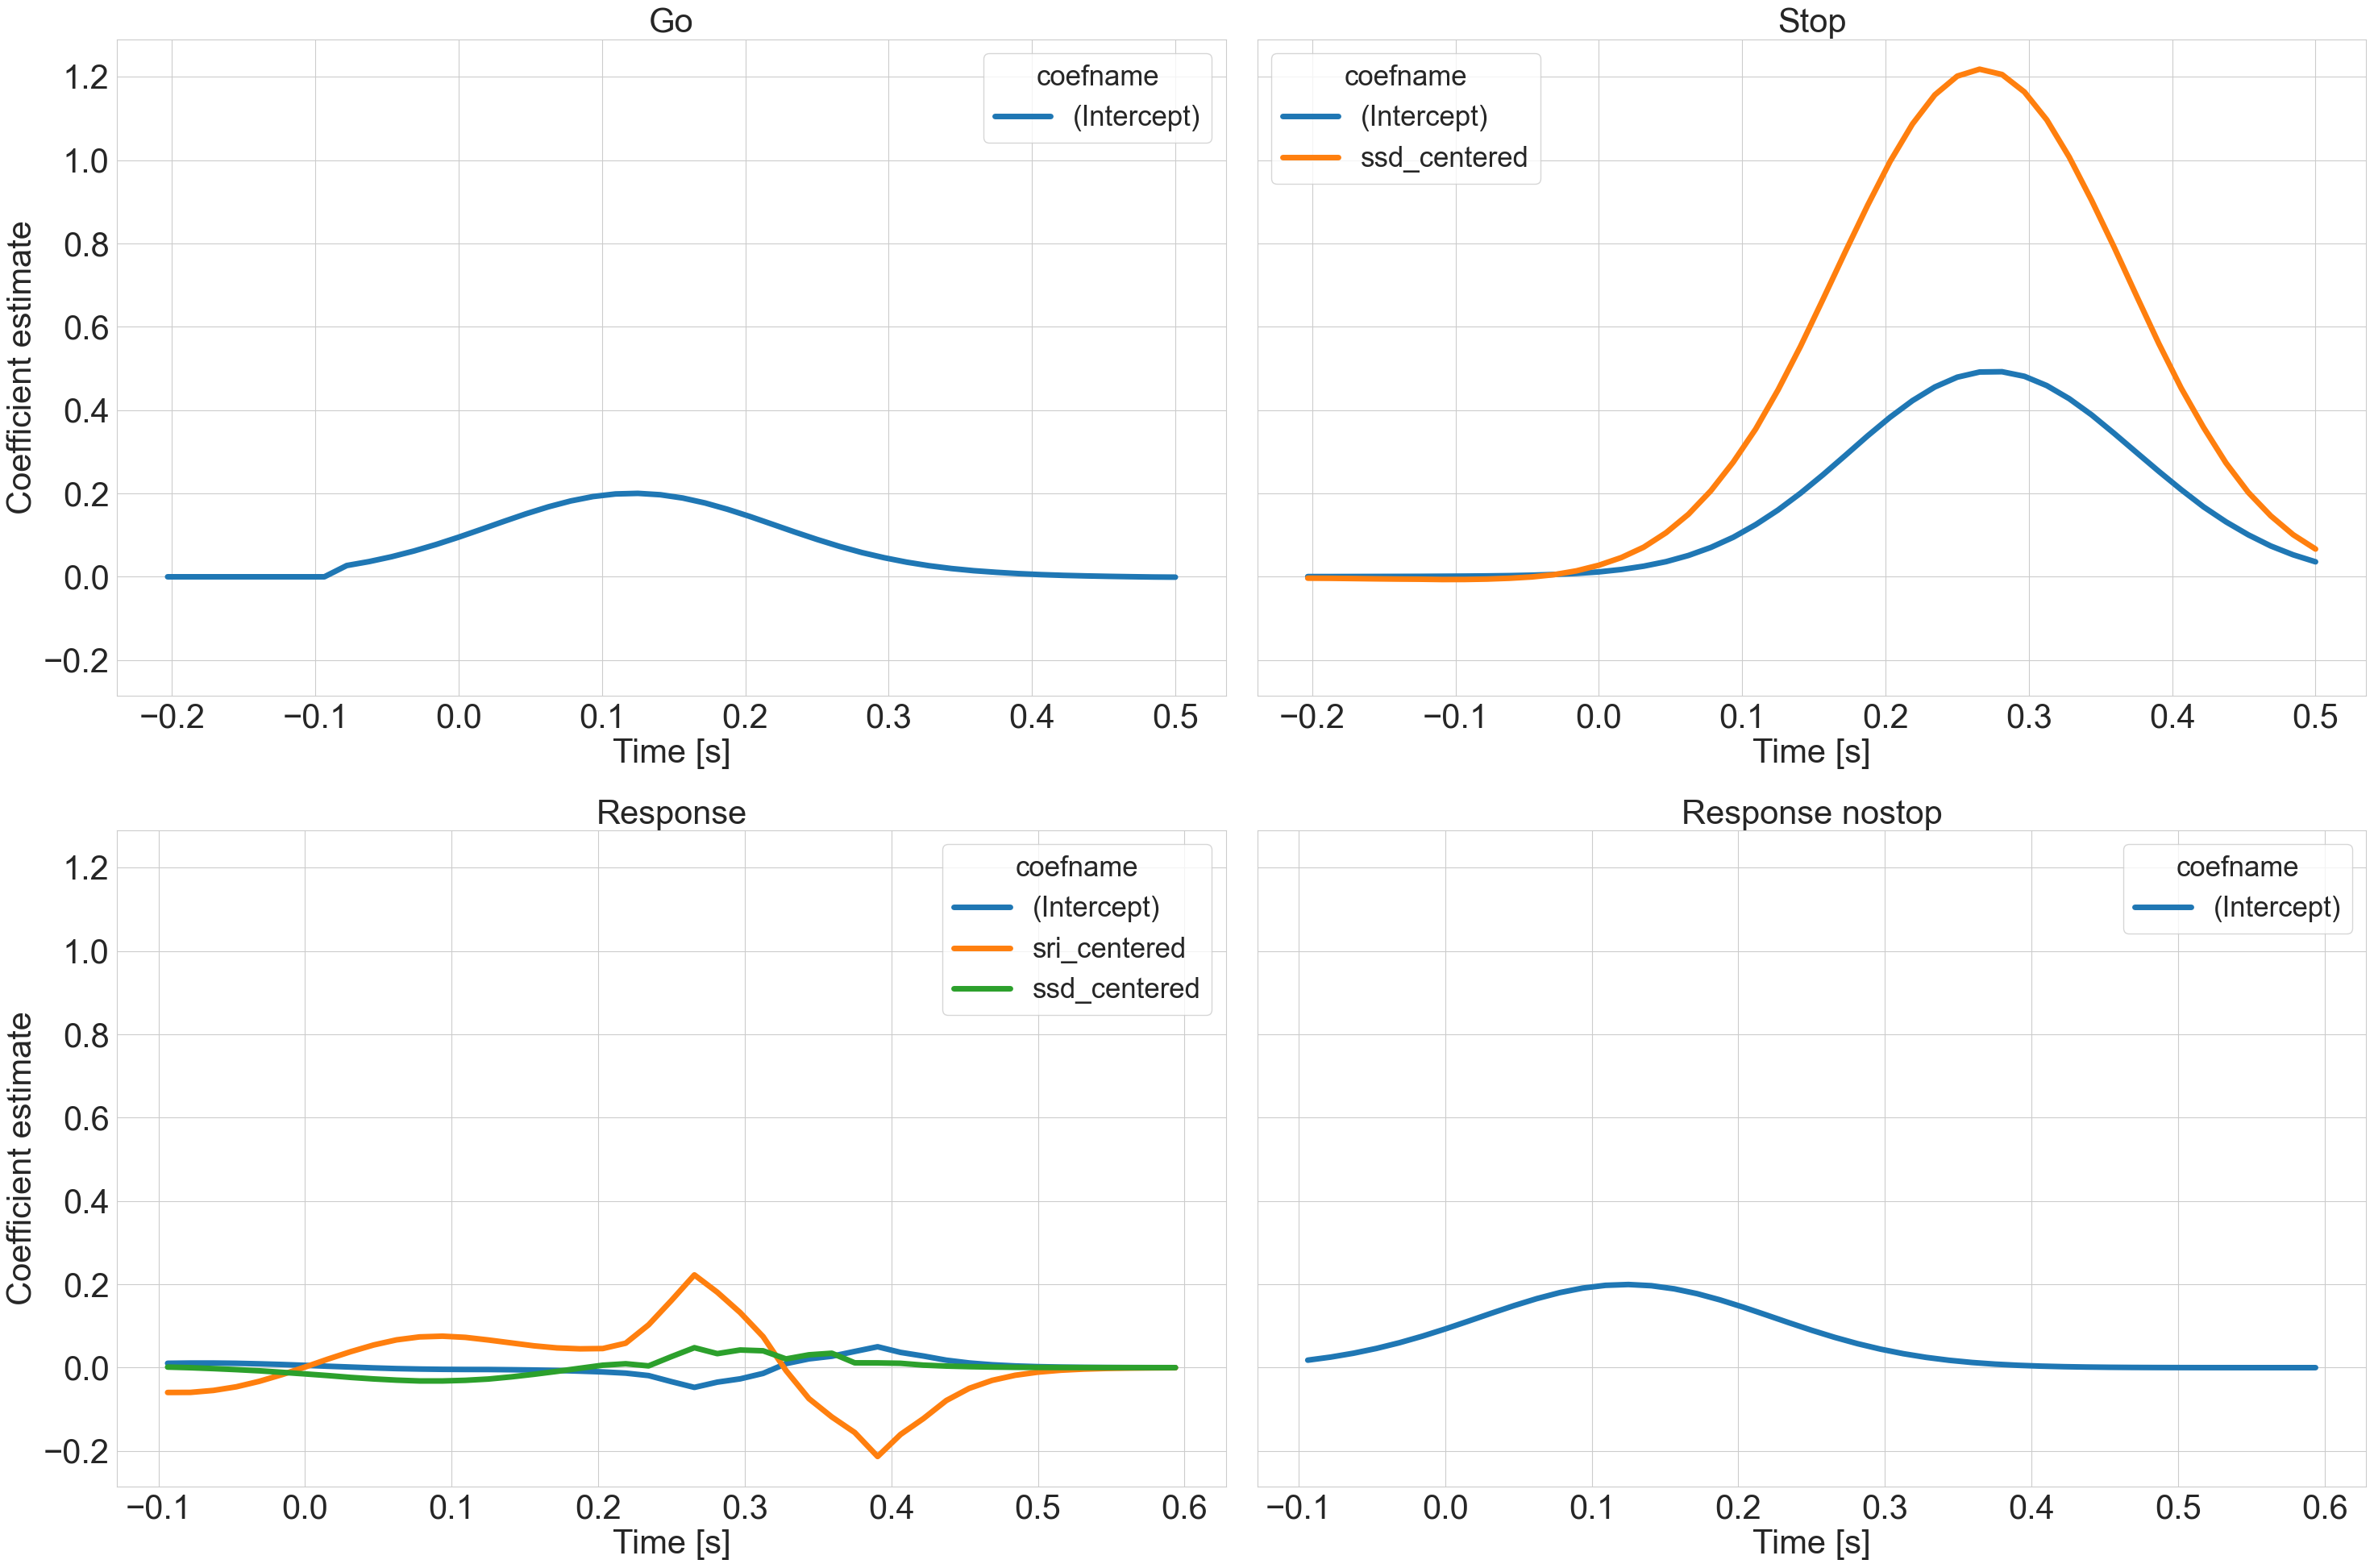

SRI mean: 0.3


<Figure size 640x480 with 0 Axes>

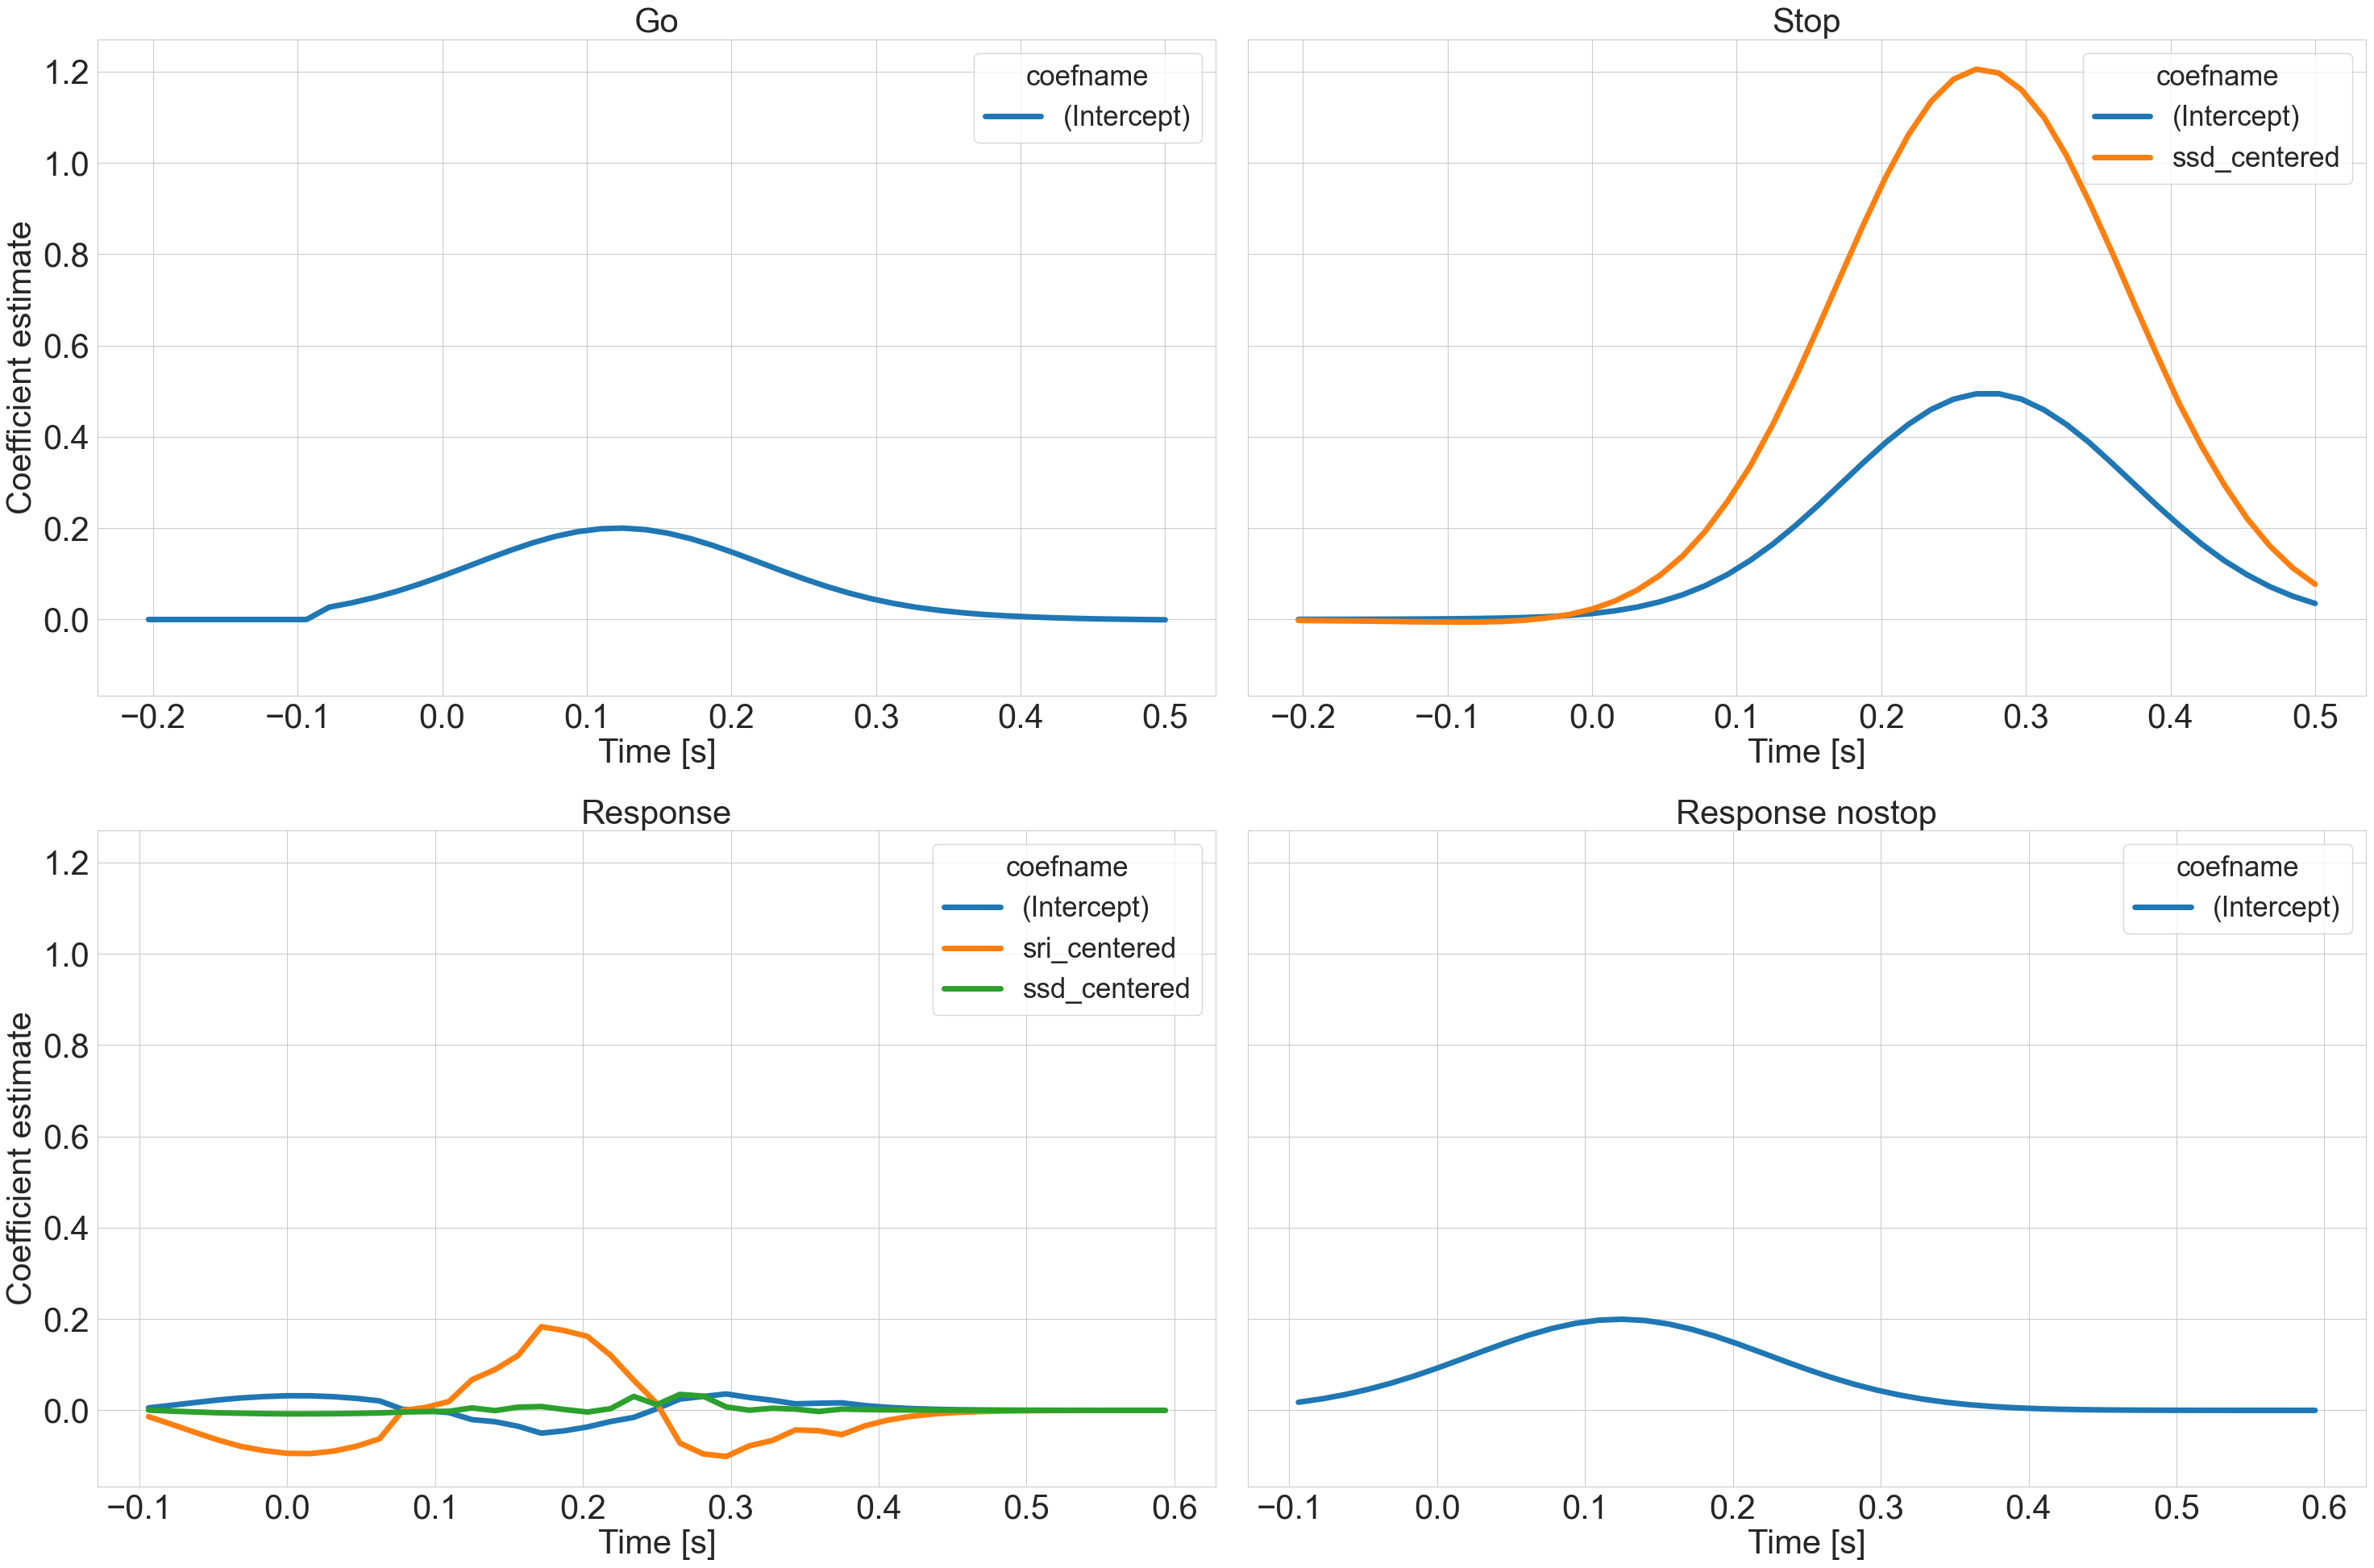

SRI mean: 0.4


<Figure size 640x480 with 0 Axes>

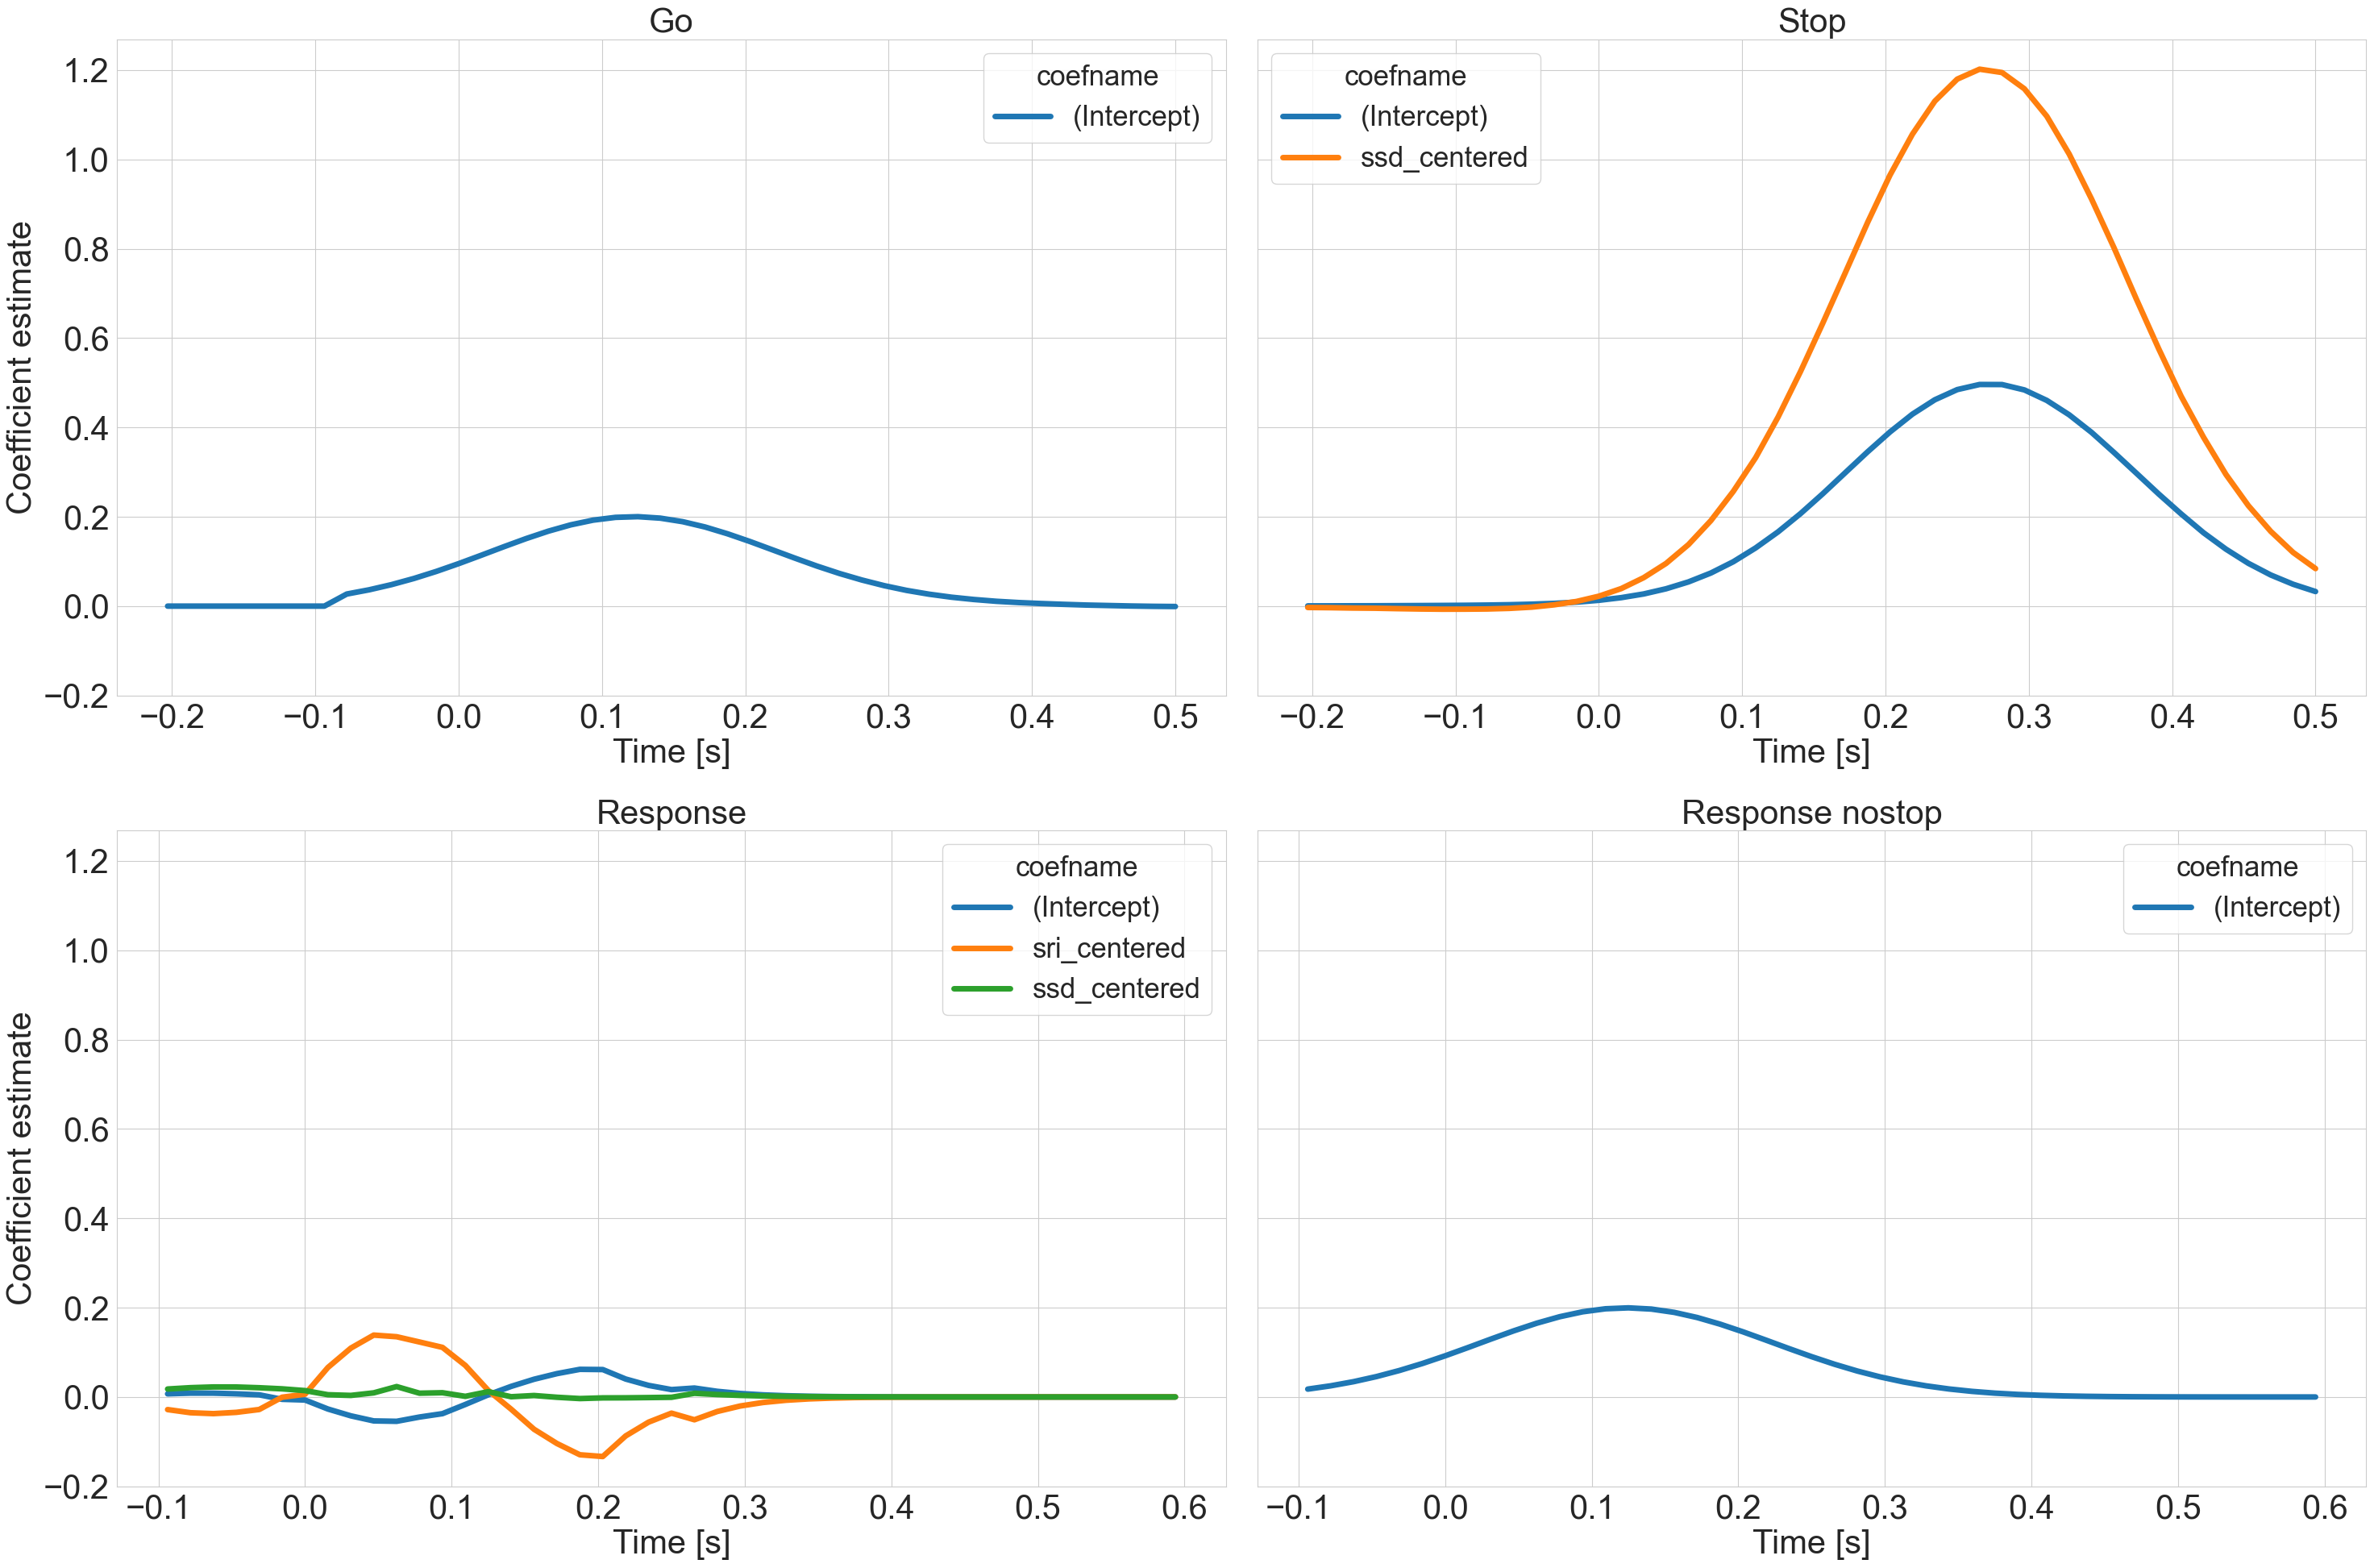

SRI mean: 0.5


<Figure size 640x480 with 0 Axes>

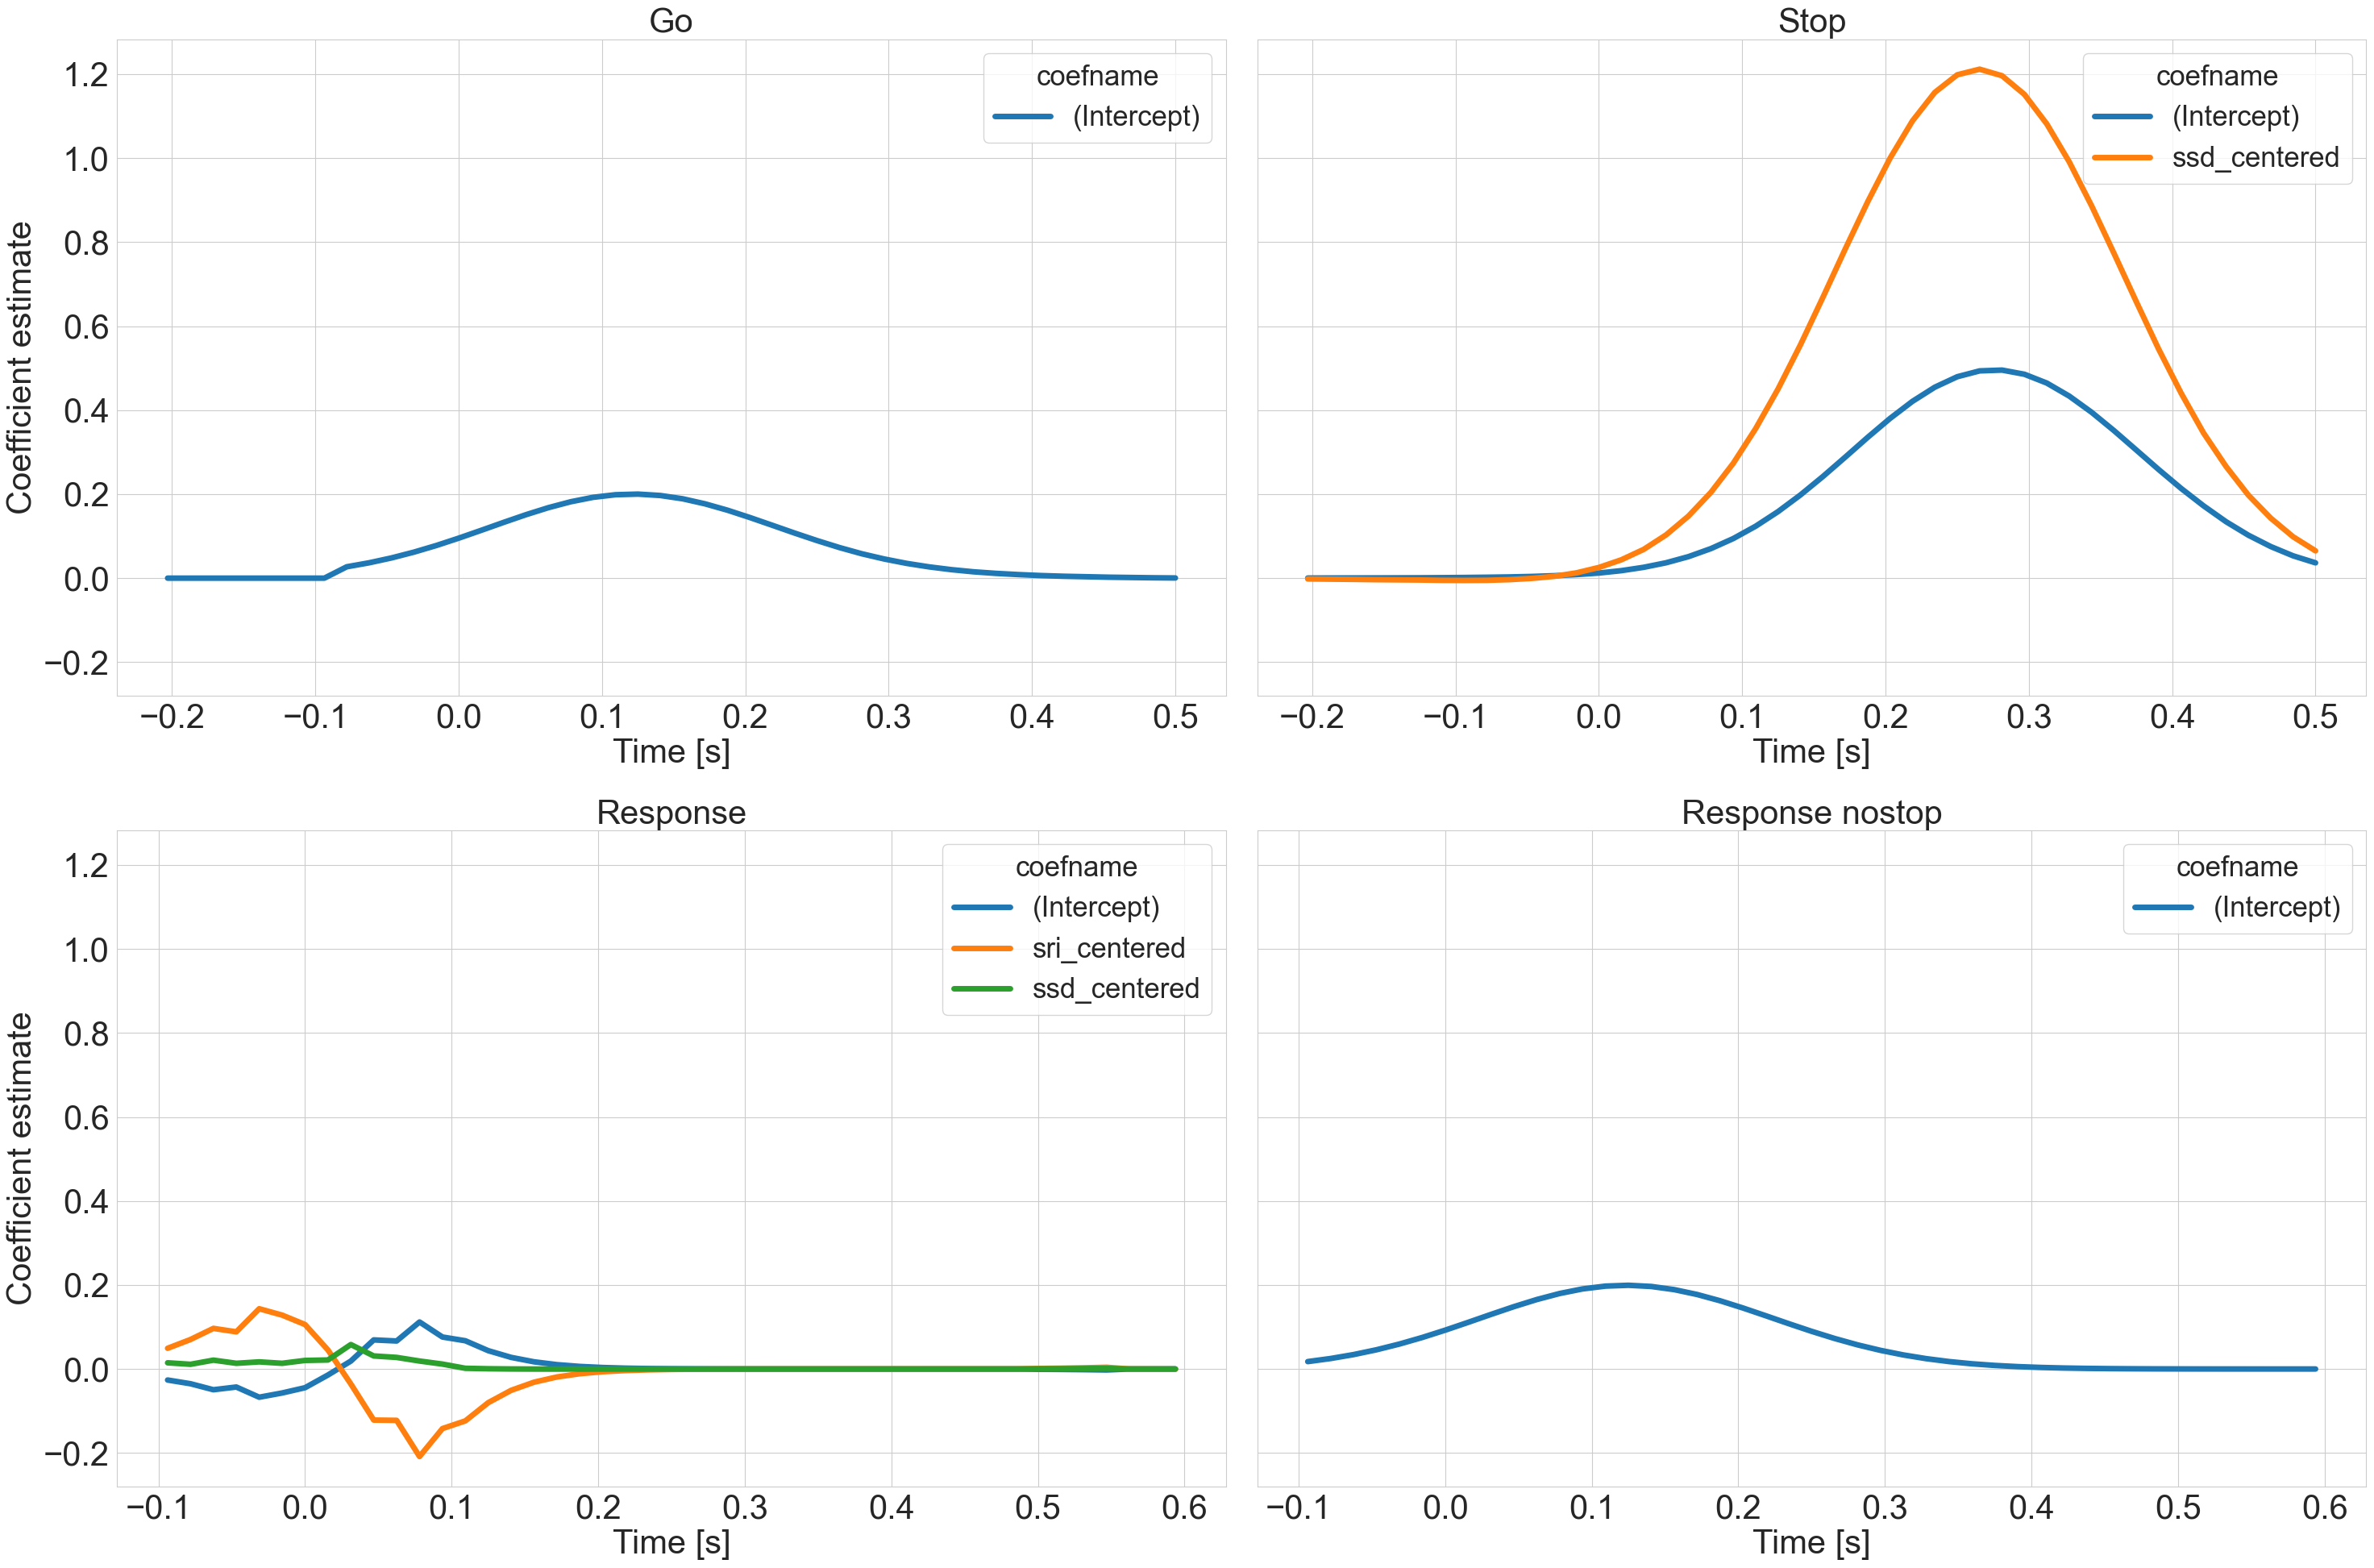

In [23]:
# Parameters
n_trials_per_ssd = 100
distances_C_A = np.arange(0.1, 0.4, 0.05)
sampling_rate = 64
noise_level = 0
duration=1.5


sri_means = [0.2, 0.3, 0.4, 0.5]

for i, sri_mean in enumerate(sri_means):
    config = {
        'go_intercept': 0.2,
        'stop_intercept': 0.5,
        'response_intercept':
            {
                'error': 1,
                'correct_nostop':0.2
            },
        'interactions': {
            'stop x SSD': True,
            'response_error x SSD': False,
            'response_error x SRI': False,
        },
        'probability': {
            'stop': 0.3,
            'error': 0.5,

        },
        'sri': {'loc': sri_mean, 'scale': 0.05}
    }

    # Simulate ERP components with conditions
    erp_trials, data_df = simulations.simulate_erp_components_with_conditions_test(
        n_trials_per_ssd,
        distances_C_A,
        config,
        sampling_rate,
        noise_level,
        duration=duration,
        stop_diff=False,
        remove_ern=True,
        stop_component_offset = .15,
    )

    # create Unfold events dataset
    events_df = simulations.create_events_table(data_df, duration, sampling_rate)

    # perform unfolding
    results = unfold_utils.perform_unfold2(events_df, erp_trials)

    # plot results
    print(f'SRI mean: {sri_mean}')
    plt.figure(i)
    unfold_utils.plot_unfold_results_sst(results)
